Using existing file wandb_summary.csv
Number of valid runs: 64

===== Average performance (sorted by val/loss) =====
          run_name  val/loss  training_time_sec
G1_ternary_weights  1.470451             785.50
    F1_context_128  1.497412             327.75
         C1_1_head  1.521530             779.75
A1_no_pos_encoding  1.566792             752.25
        B2_post_ln  1.571725             735.25
           D1_relu  1.604403             713.75
E1_scaled_residual  1.680248             720.25
        B1_rmsnorm  1.691510             954.50
          baseline  1.694434             728.00
        C2_8_heads  1.703495             759.50
       C3_12_heads  1.711966             748.75
           A2_rope  1.736691             900.25
          A3_alibi  1.813359            1374.50
         D2_swiglu  1.887586             788.75
    F2_context_512  2.010515            1541.50
   E2_no_residuals  3.357021             667.00


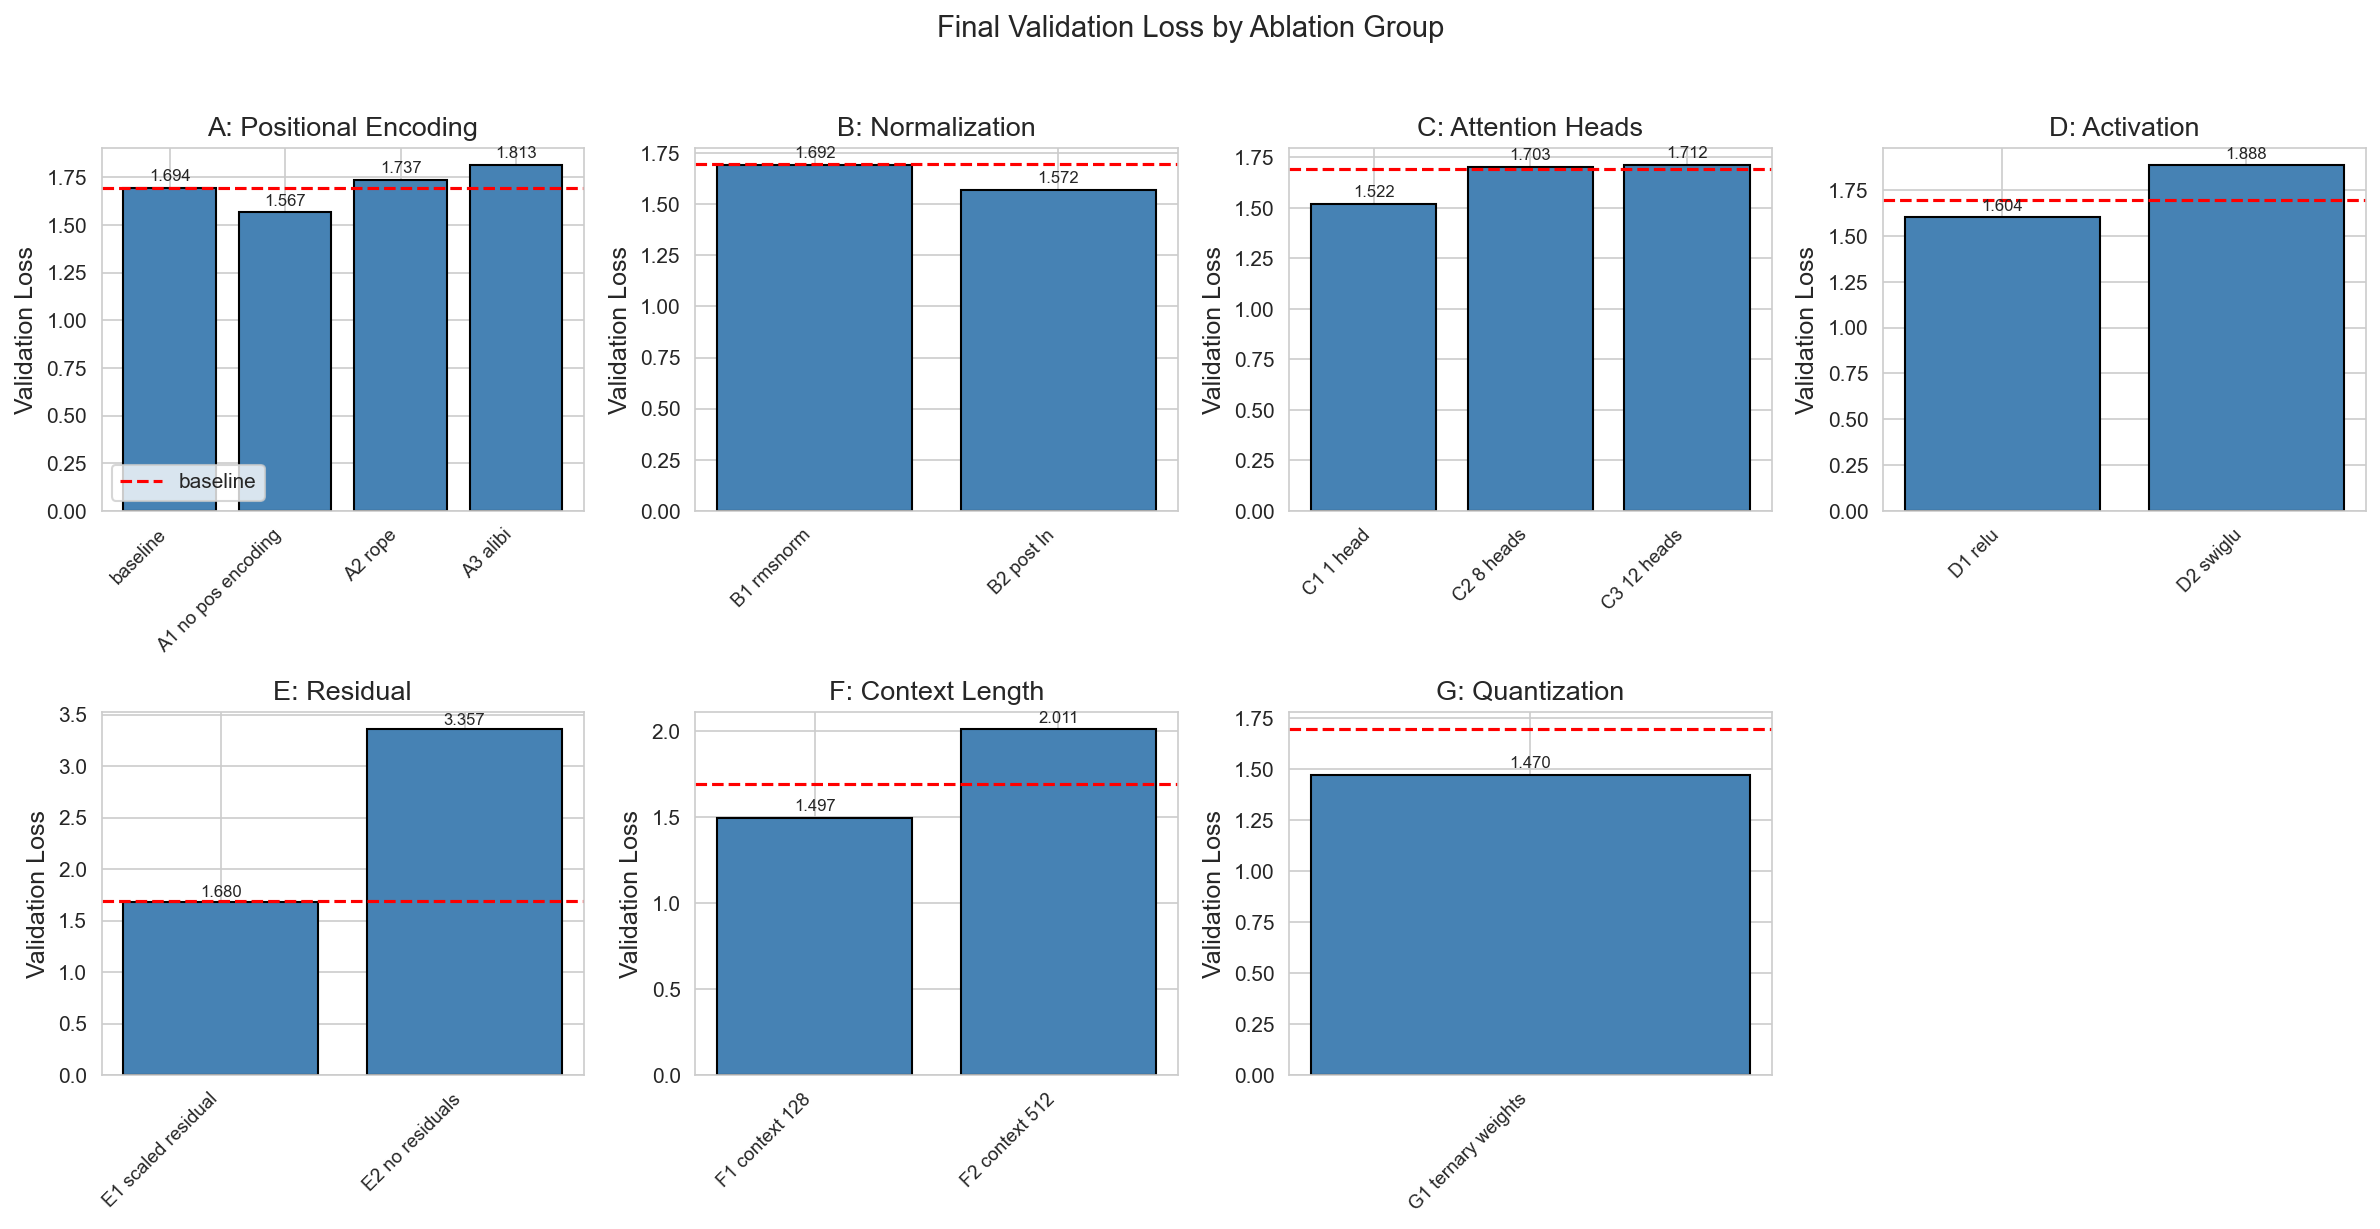

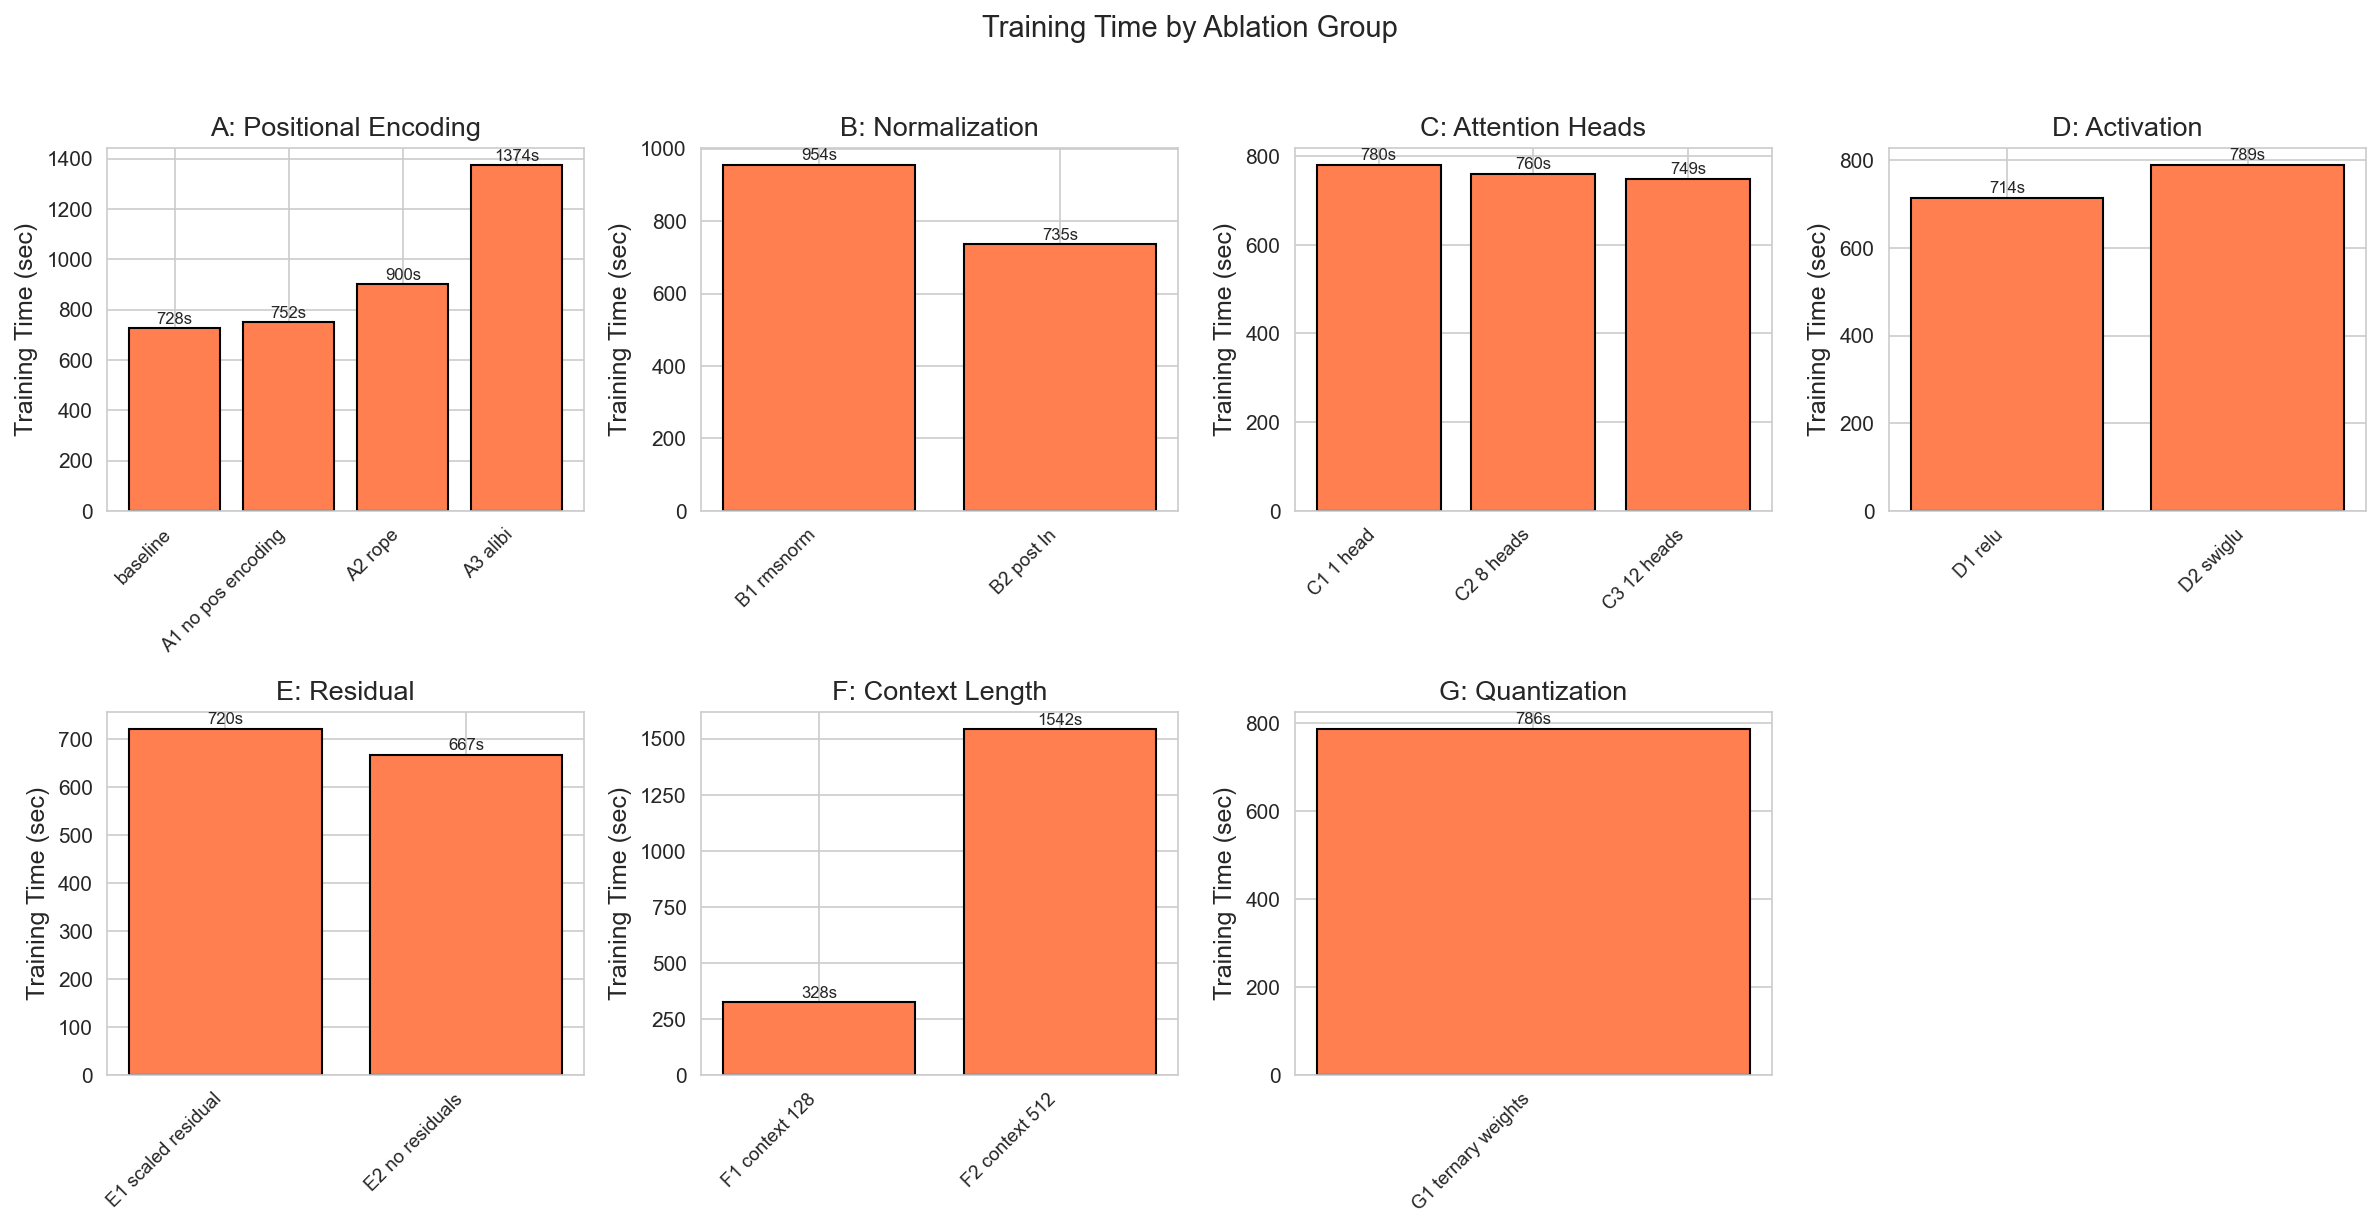


Skipping baseline (cpc0g0we) - already downloaded
Skipping A1_no_pos_encoding (et6cq3h8) - already downloaded
Skipping A2_rope (f1hcag99) - already downloaded
Skipping A3_alibi (kyg1ahnh) - already downloaded
Skipping B1_rmsnorm (1wotqmtu) - already downloaded
Skipping B2_post_ln (1qjwf3pi) - already downloaded
Skipping C1_1_head (hf9s97ue) - already downloaded
Skipping C2_8_heads (fk58f1mb) - already downloaded
Skipping C3_12_heads (ldzl9or7) - already downloaded
Skipping D1_relu (uqr8b9q8) - already downloaded
Skipping D2_swiglu (suvqluat) - already downloaded
Skipping E1_scaled_residual (q71yvqap) - already downloaded
Skipping E2_no_residuals (07swdfwz) - already downloaded
Skipping F1_context_128 (rwyr9wzu) - already downloaded
Skipping F2_context_512 (narqzlgt) - already downloaded
Skipping G1_ternary_weights (cyeok0ie) - already downloaded
Skipping baseline (0z5e2sya) - already downloaded
Skipping A1_no_pos_encoding (xqwm1e1v) - already downloaded
Skipping A2_rope (g77717h6) - a

C:\Users\Rickey\AppData\Local\Temp\ipykernel_25536\661566909.py:233: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conv_steps = combined_hist.groupby(['run_name', 'run_id']).apply(


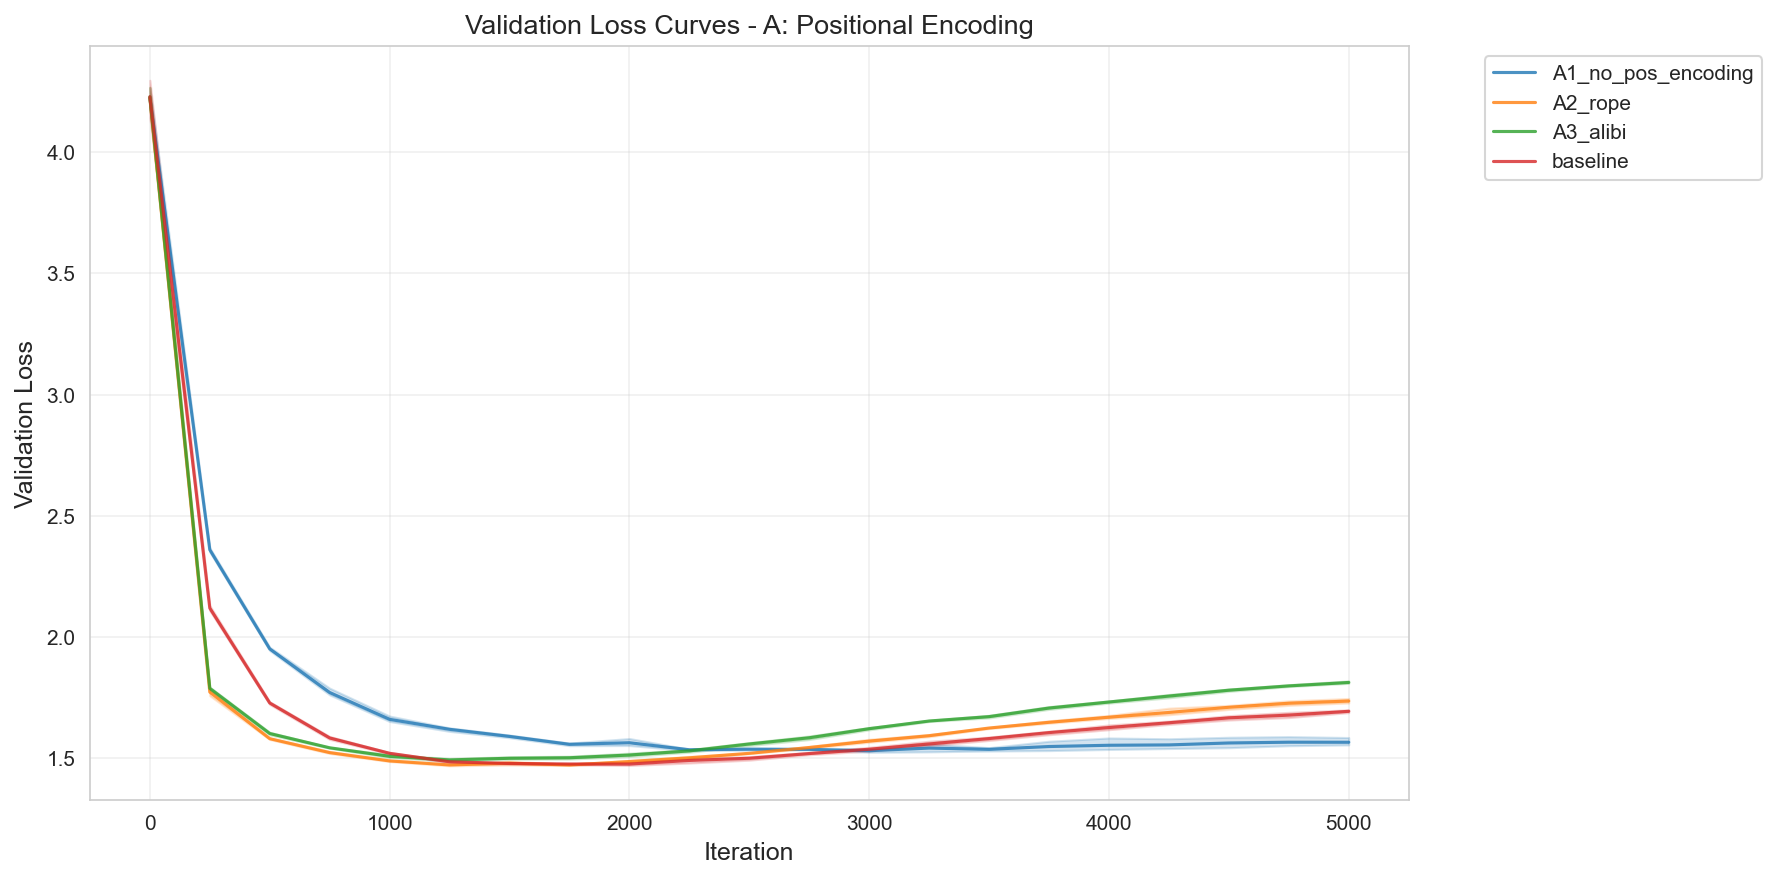

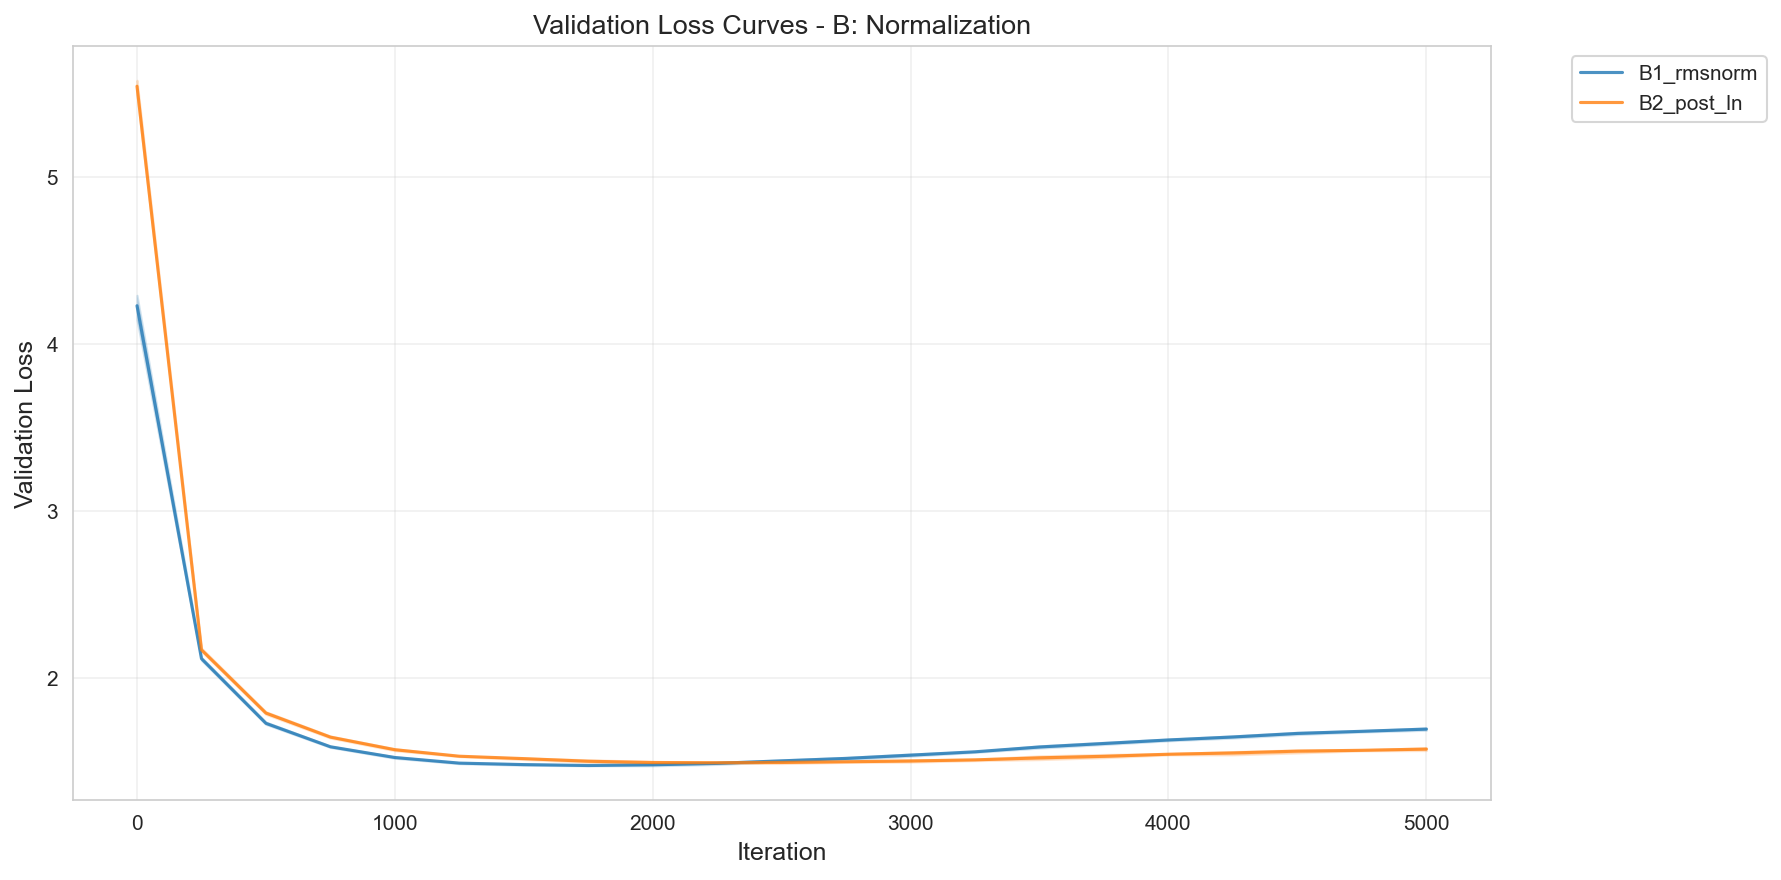

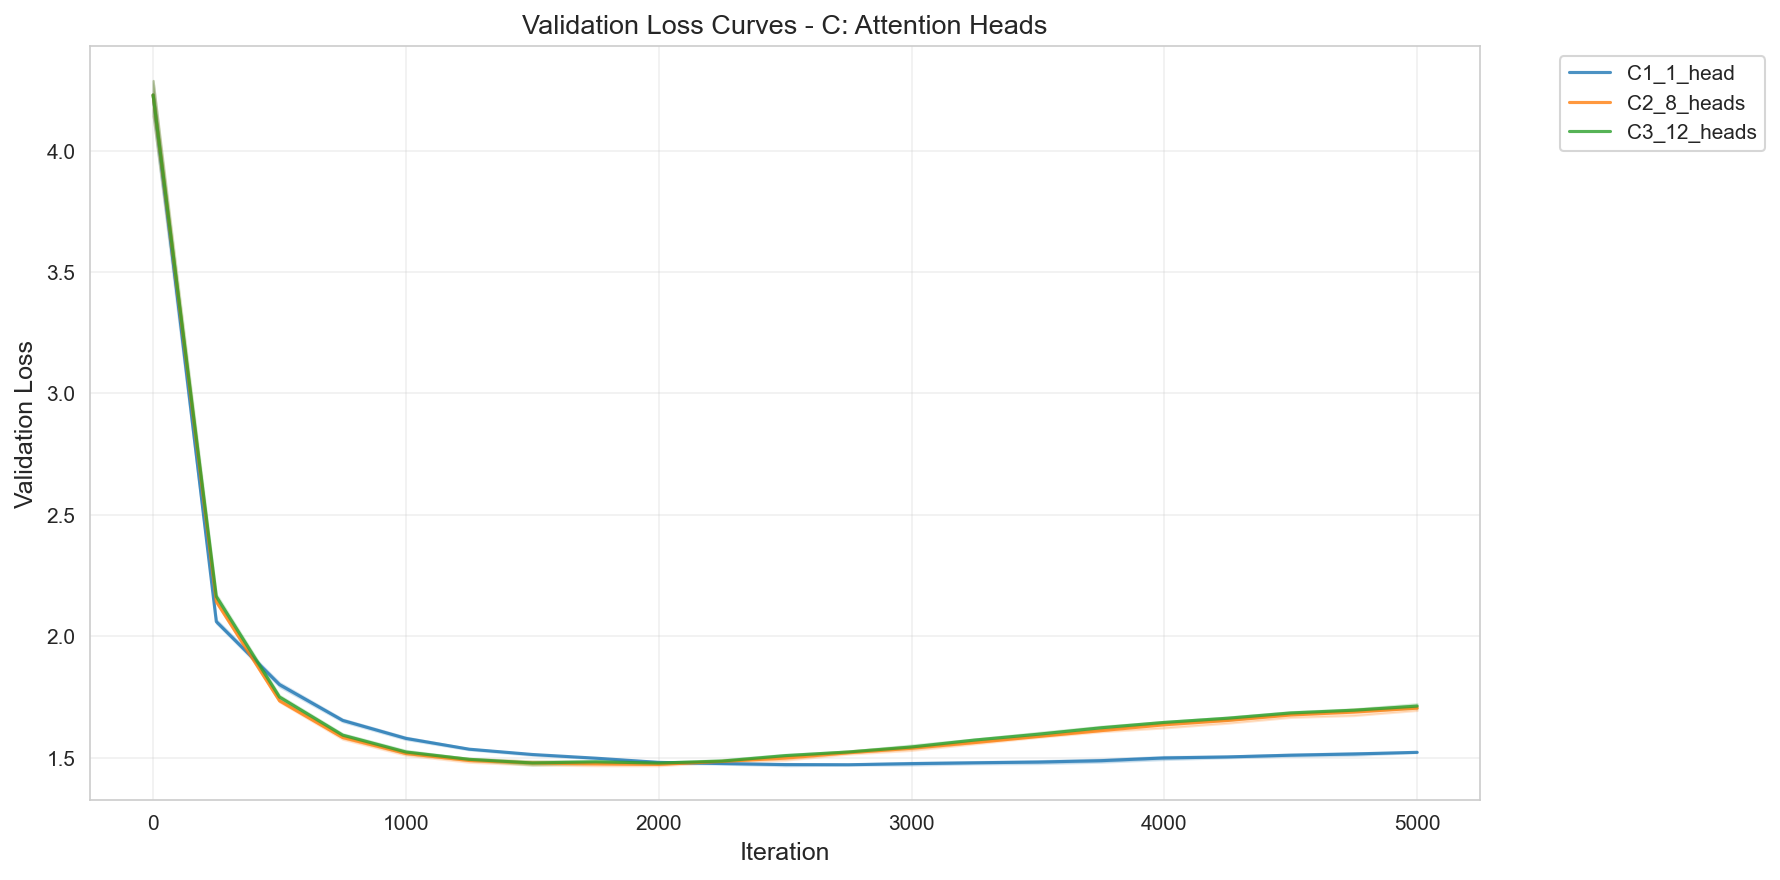

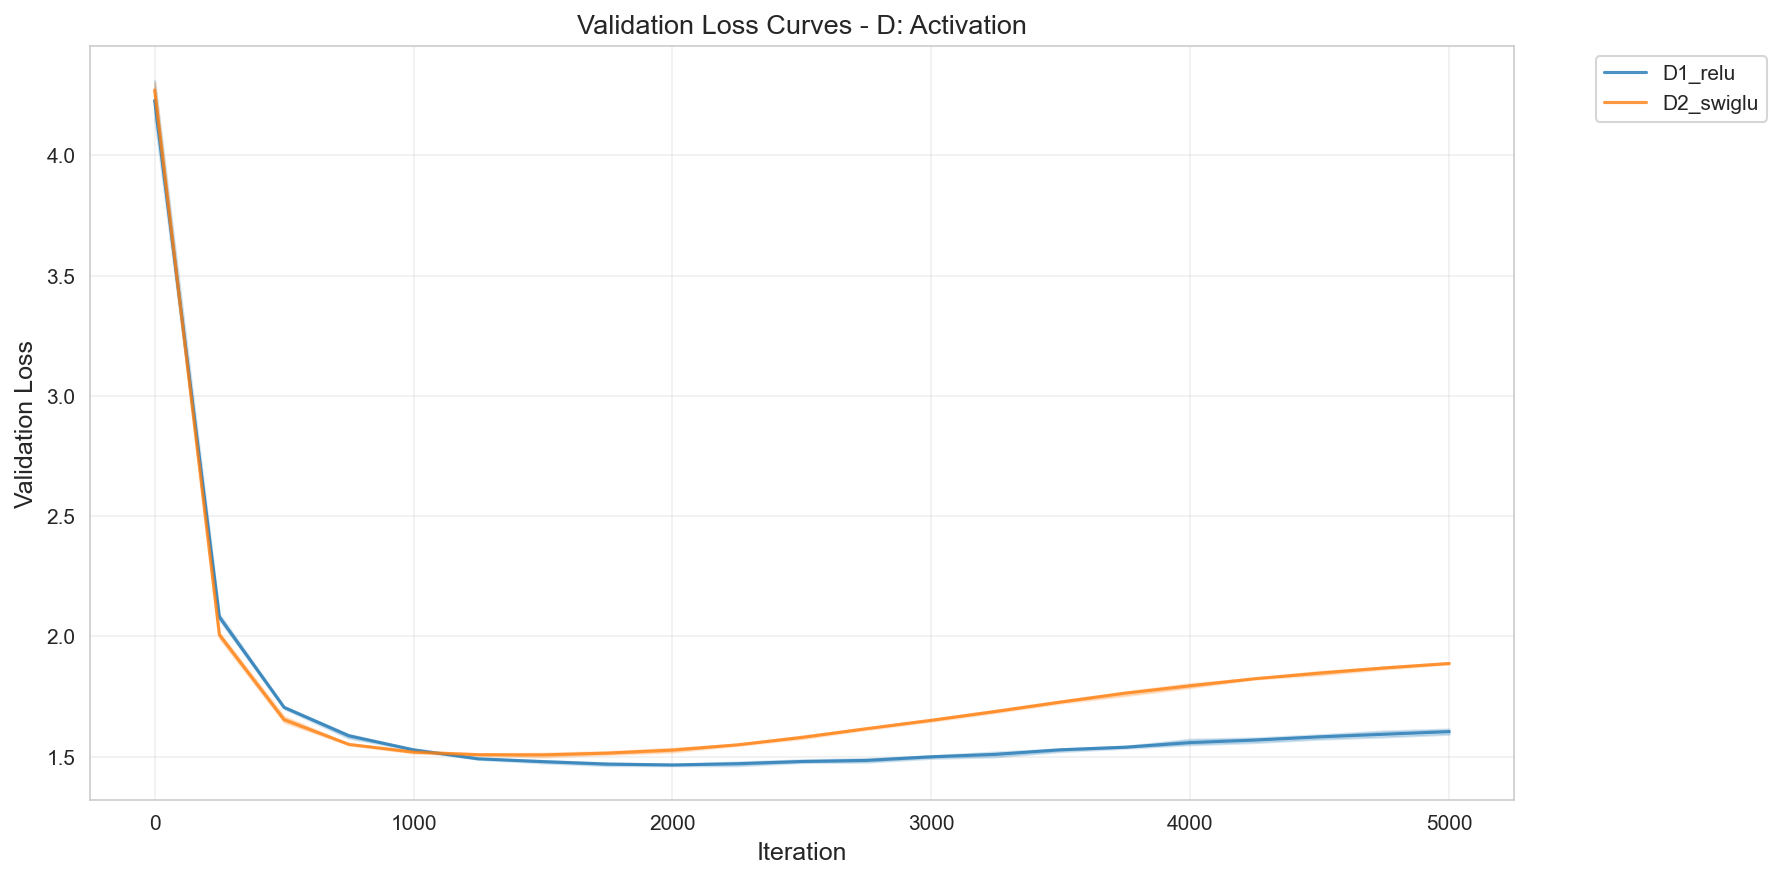

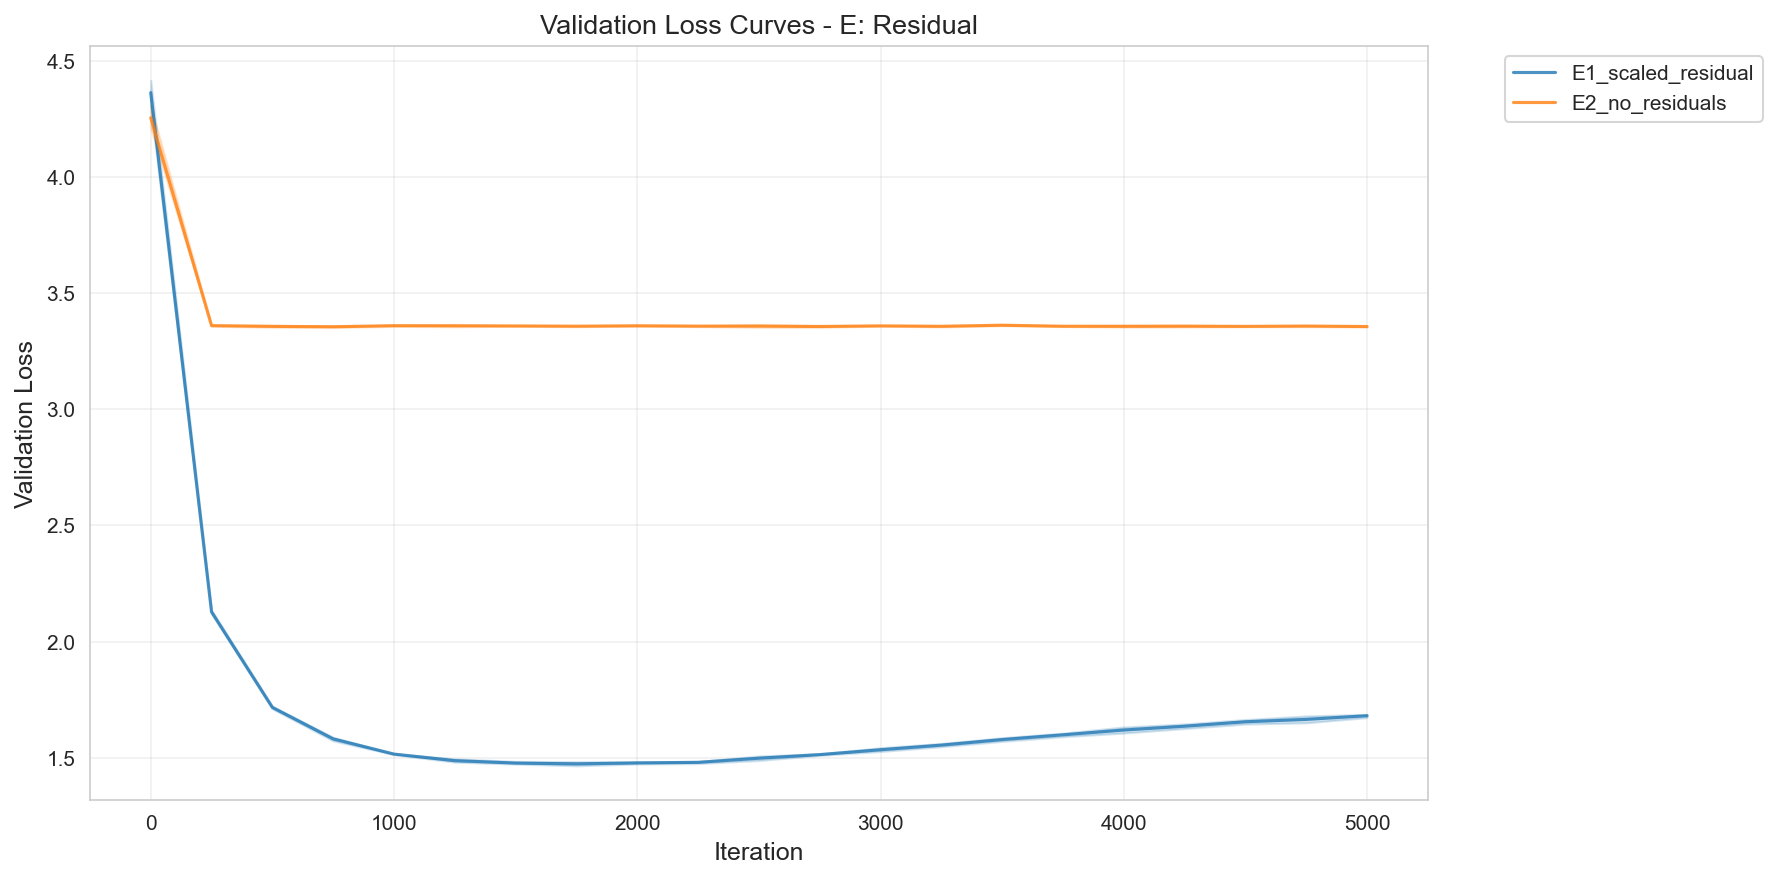

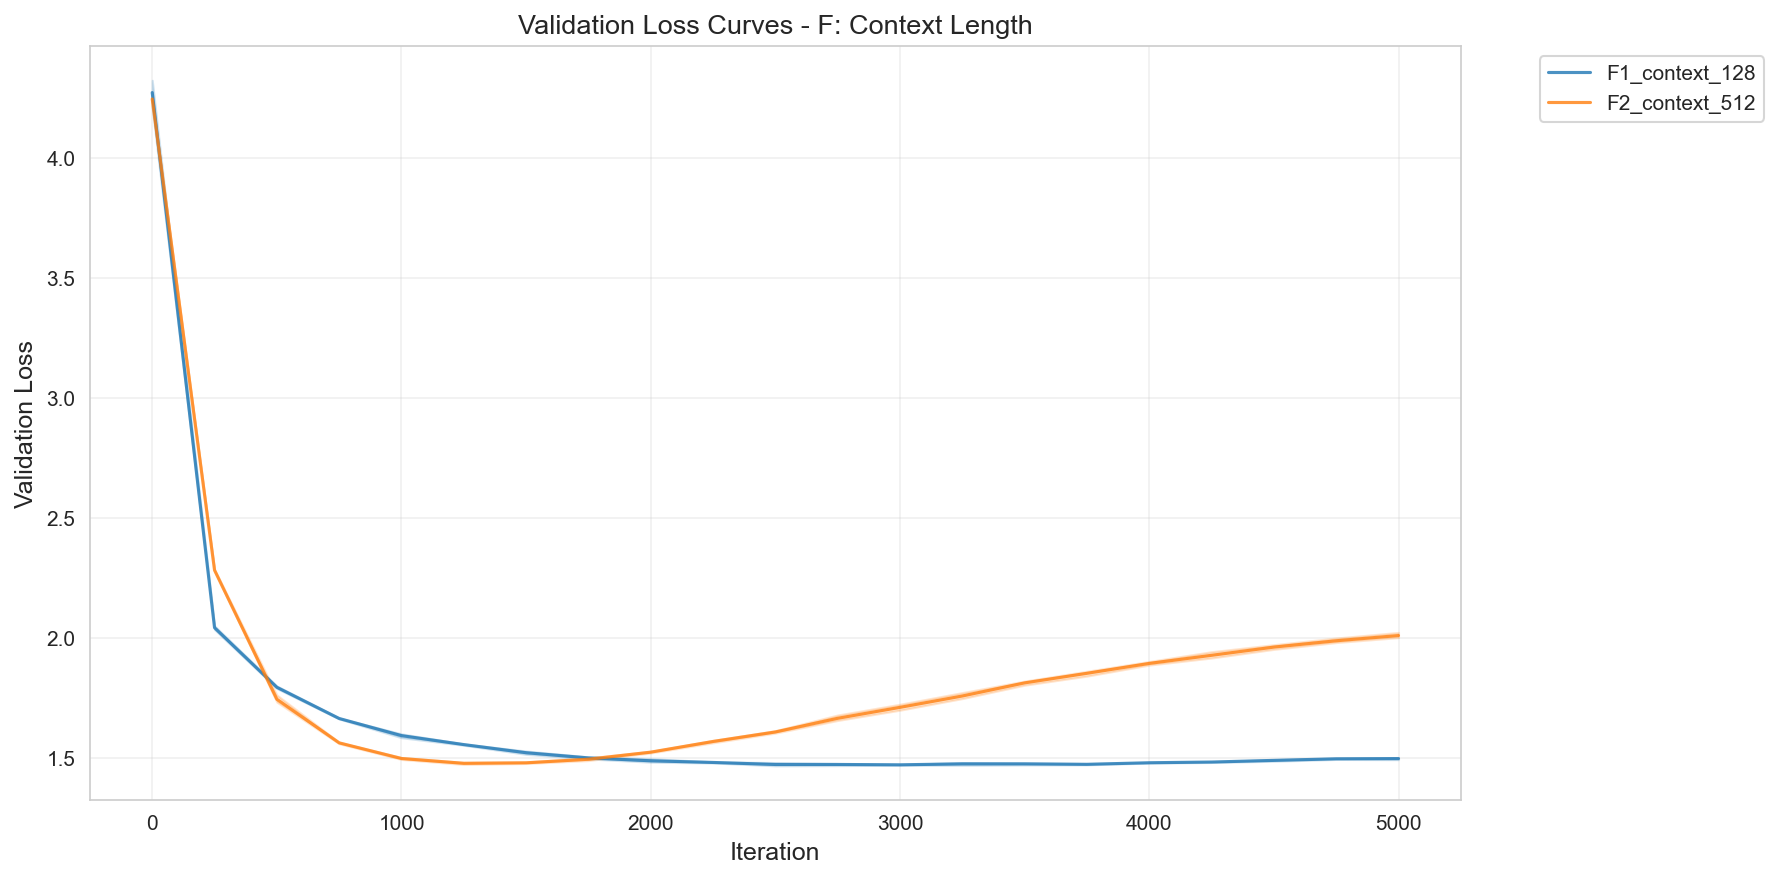

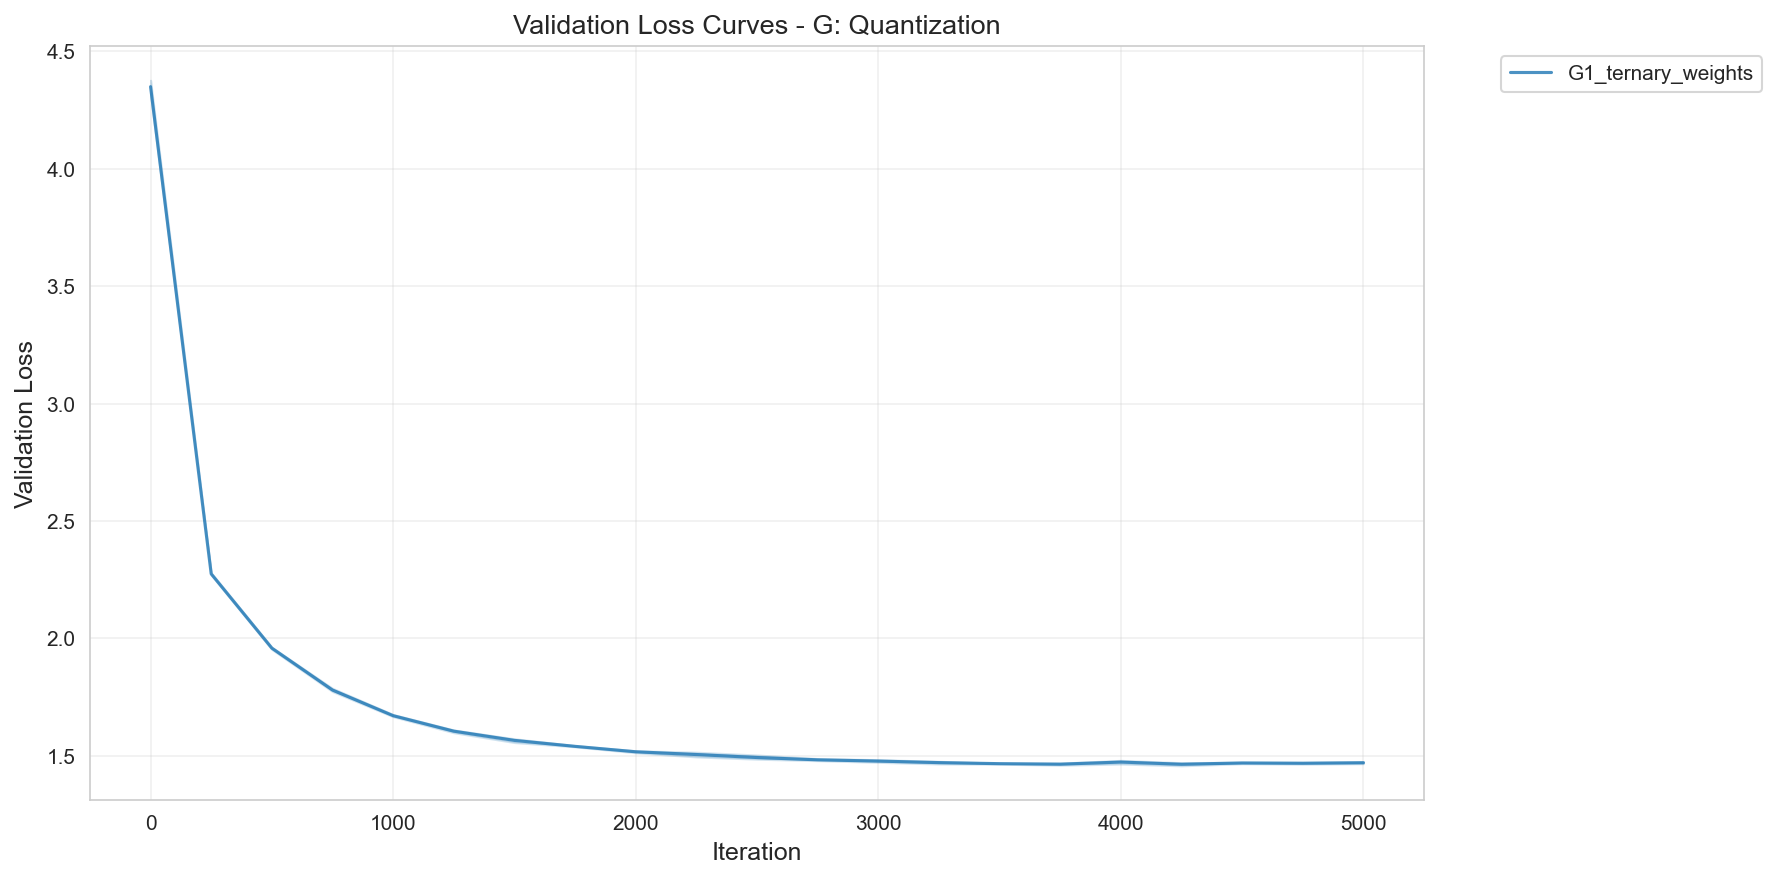

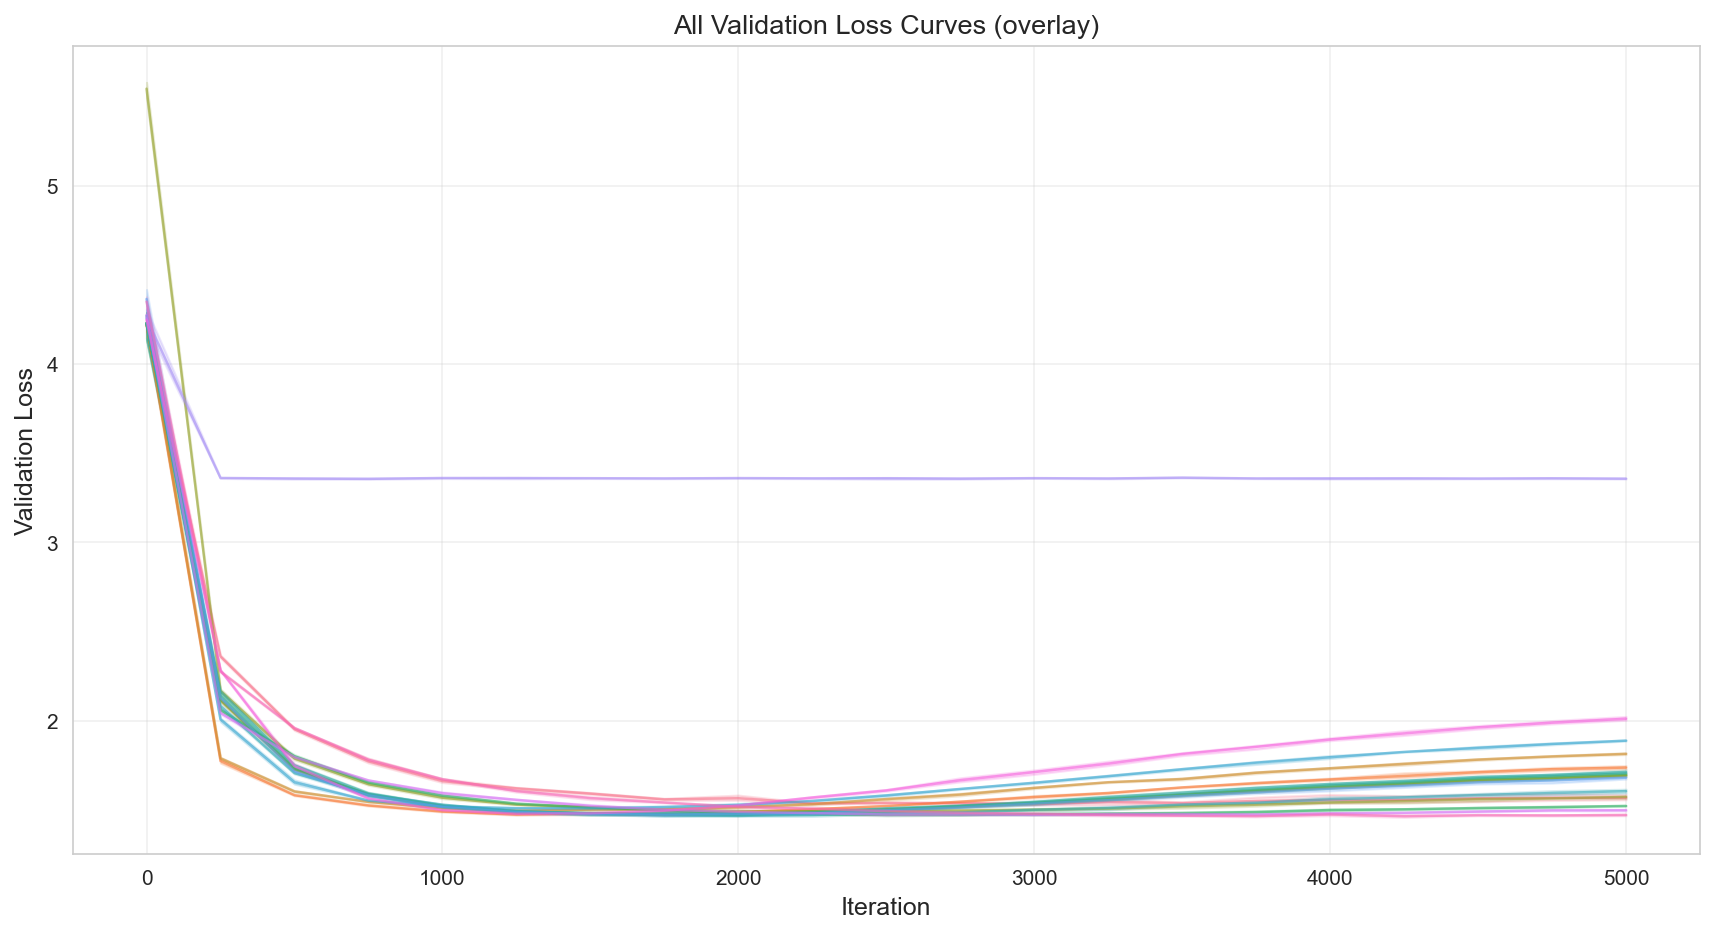


Saved output\baseline_sample.txt
Saved output\A1_no_pos_encoding_sample.txt
Saved output\E2_no_residuals_sample.txt
Saved output\G1_ternary_weights_sample.txt

Summary table saved to analysis_figures\summary_table.csv
                 Group      Configuration  Val Loss  Δ from baseline  Training Time (s)  Params (M)
A: Positional Encoding A1 no pos encoding    1.5668          -0.1276              752.2       10.65
A: Positional Encoding            A2 rope    1.7367           0.0423              900.2       10.65
A: Positional Encoding           A3 alibi    1.8134           0.1189             1374.5       10.65
A: Positional Encoding           baseline    1.6944           0.0000              728.0       10.75
      B: Normalization         B1 rmsnorm    1.6915          -0.0029              954.5       10.75
      B: Normalization         B2 post ln    1.5717          -0.1227              735.2       10.75
    C: Attention Heads          C1 1 head    1.5215          -0.1729             

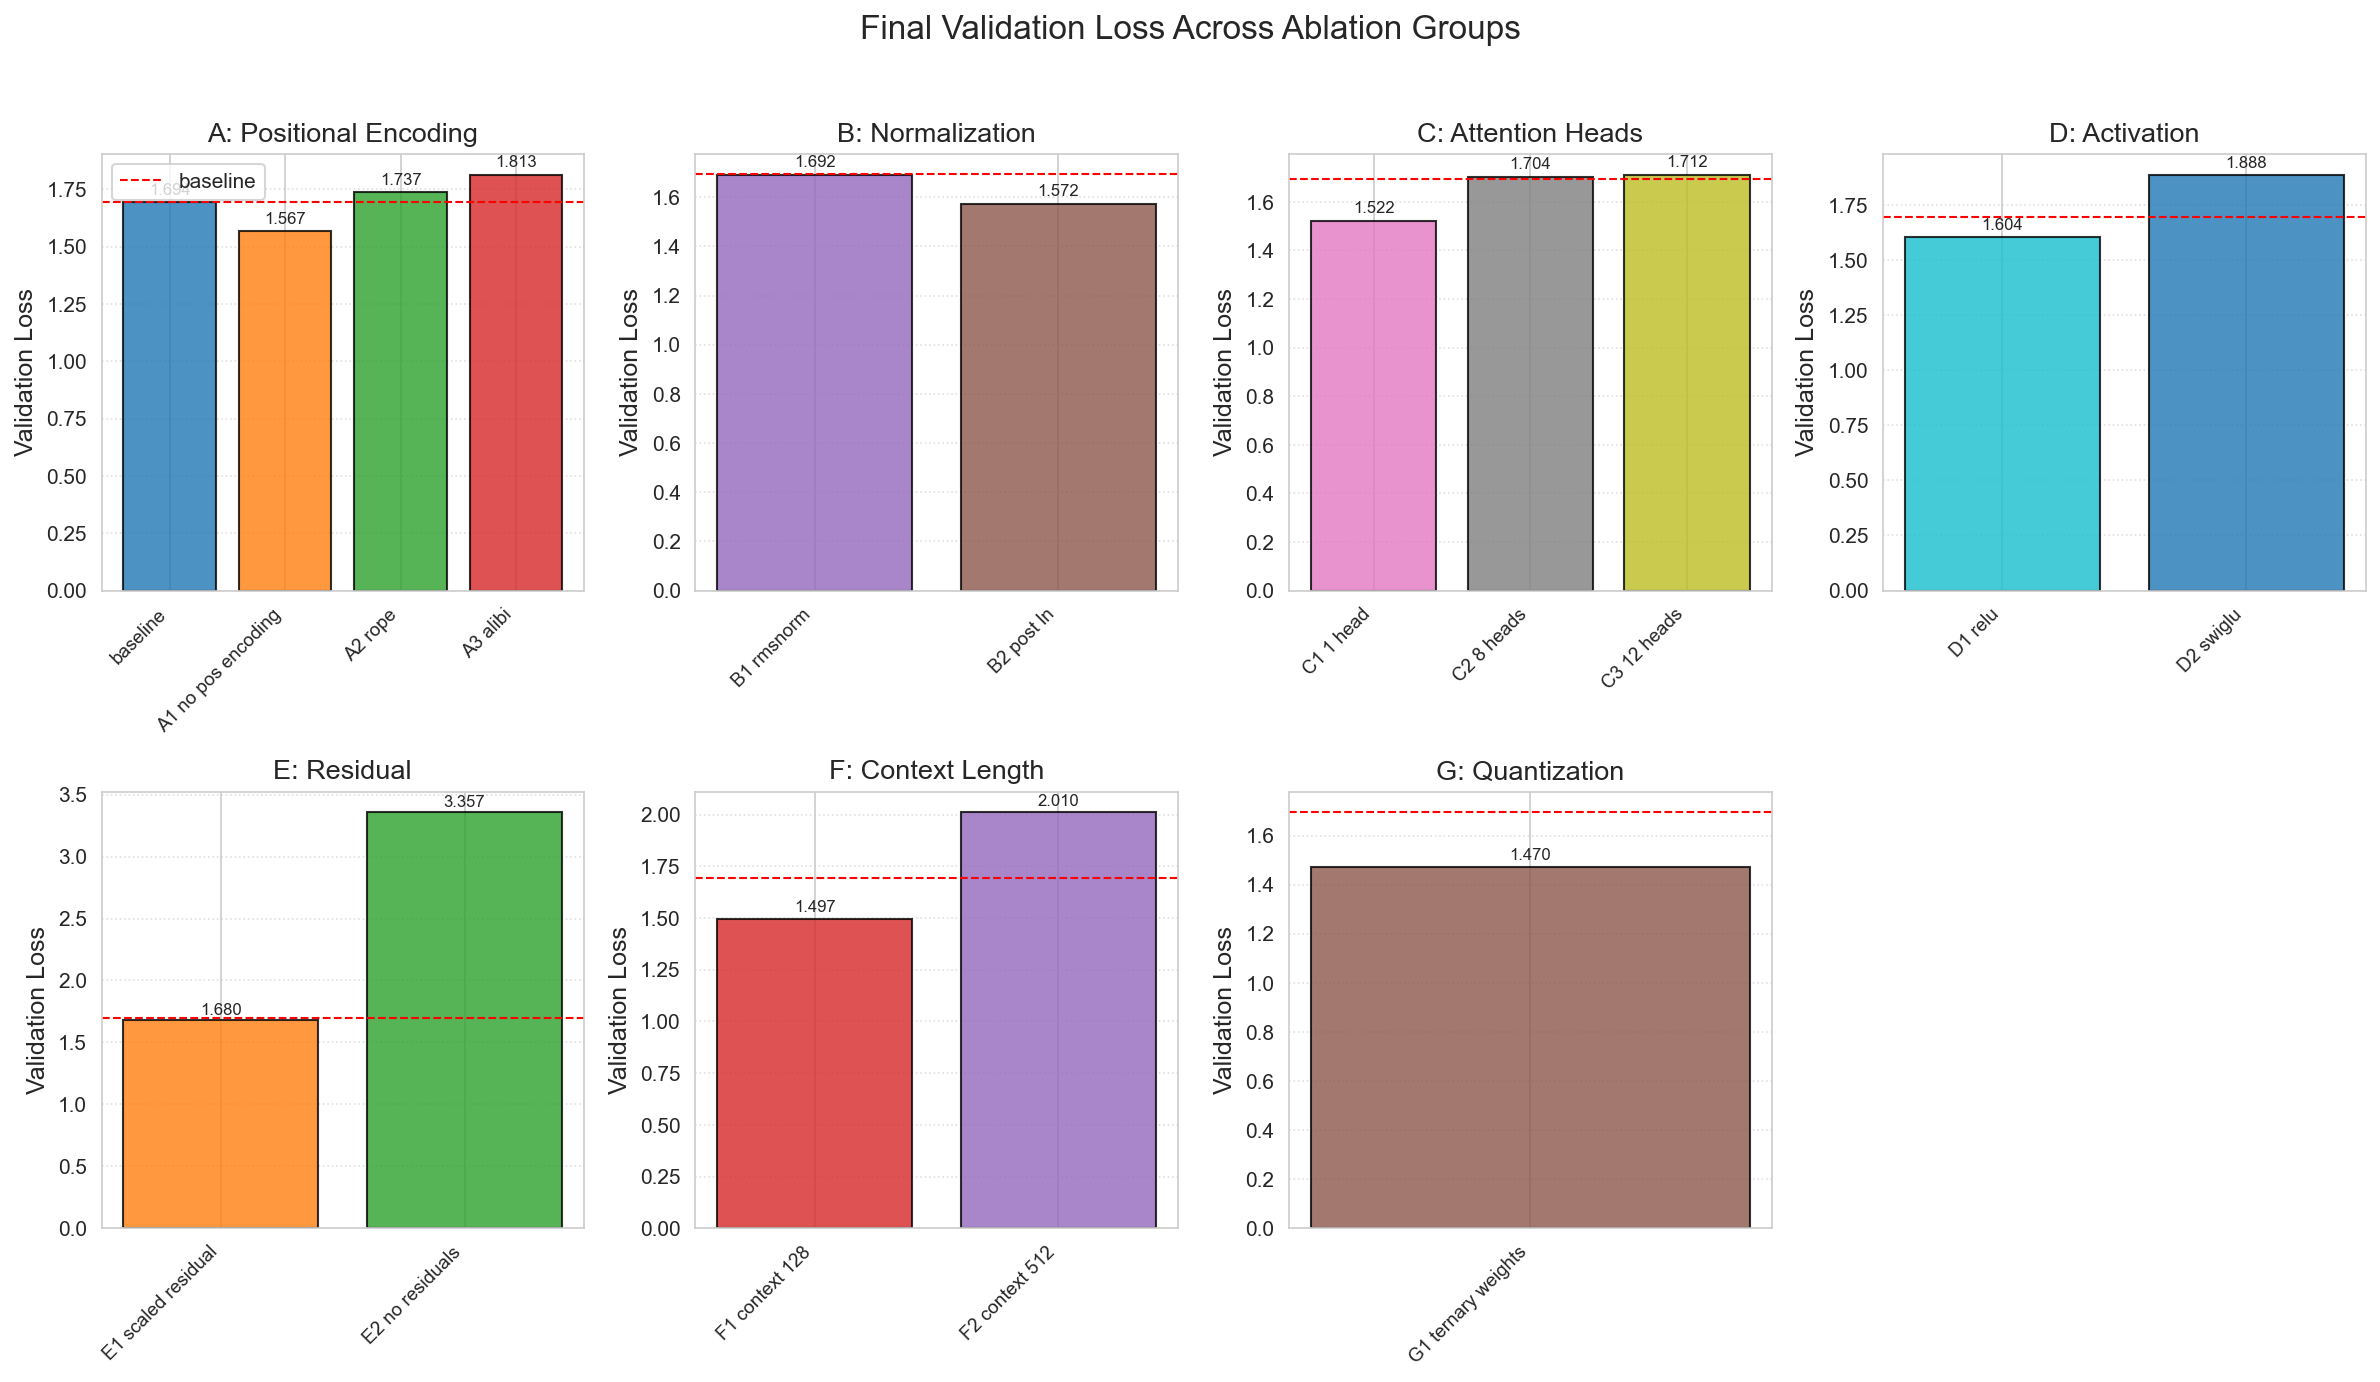

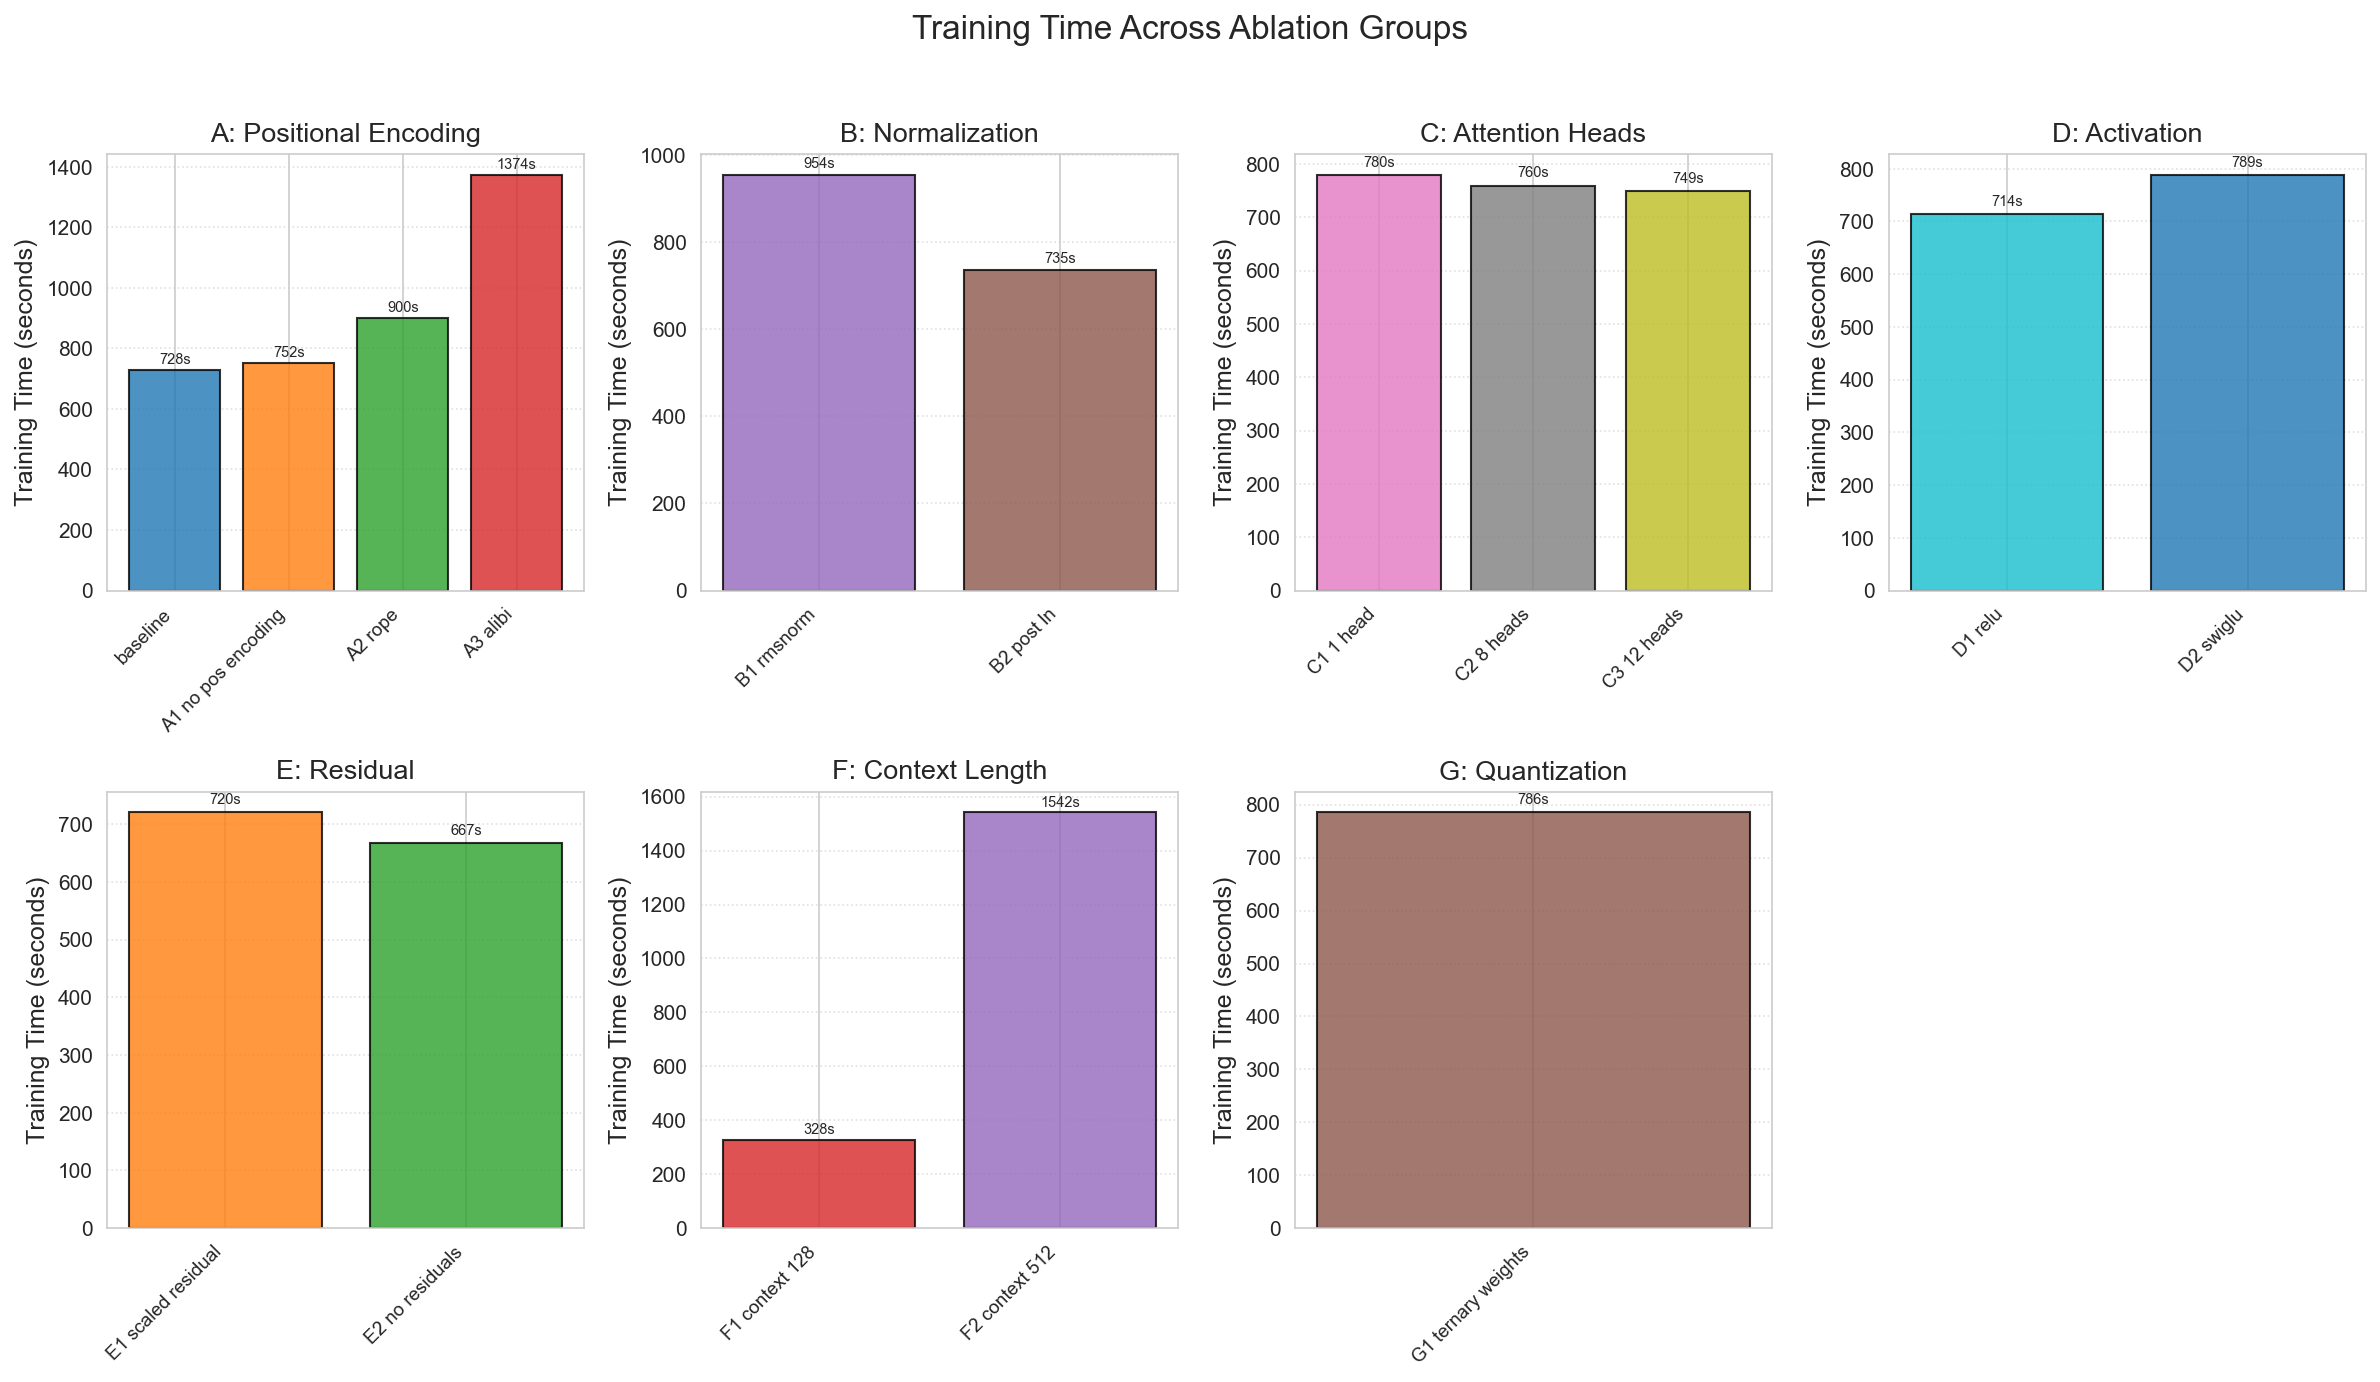

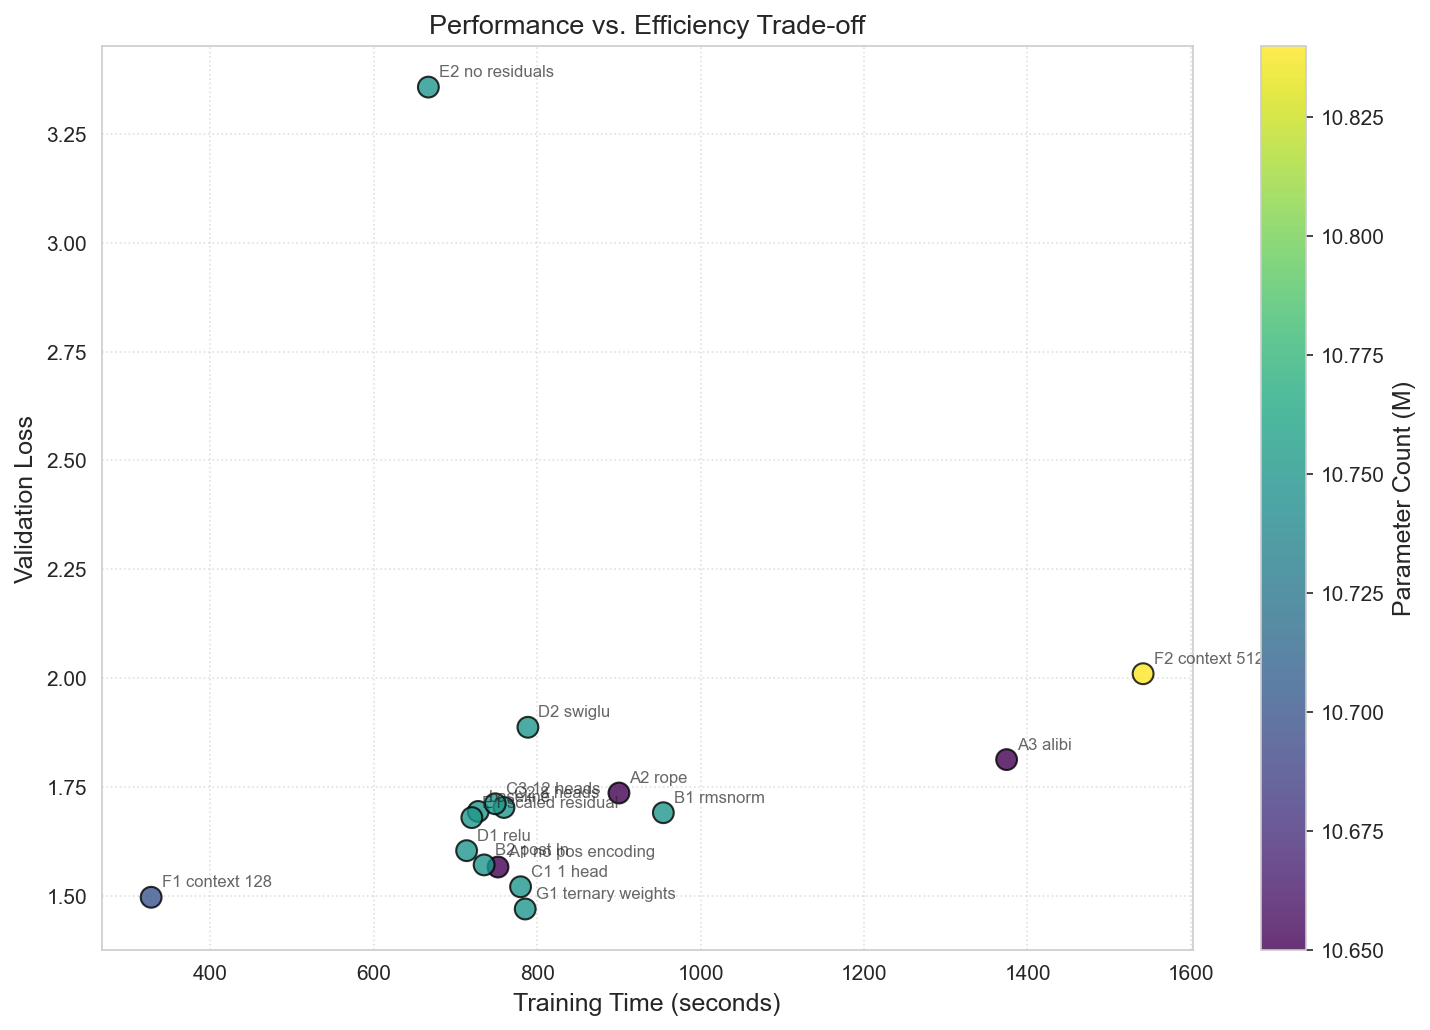


All analysis completed.


In [7]:
#!/usr/bin/env python
# coding: utf-8

# ==================================================
# Complete Experiment Results Analysis Notebook
# ==================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from bs4 import BeautifulSoup
import time

# ----- Configuration -----
ENTITY = "madhavkrishnan747-australian-national-university"
PROJECT = "nanogpt-ablations"
SUMMARY_CSV = "wandb_summary.csv"
OUTPUT_DIR = "analysis_figures"
HISTORY_DIR = "history_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 150

# ==================================================
# 1. Fetch or load summary data from wandb (keep _runtime)
# ==================================================
def fetch_or_load_summary(force_refresh=False):
    """Load cached summary CSV or fetch fresh data from wandb."""
    if not force_refresh and os.path.exists(SUMMARY_CSV):
        print(f"Using existing file {SUMMARY_CSV}")
        return pd.read_csv(SUMMARY_CSV)
    
    print("Fetching data from wandb...")
    api = wandb.Api()
    runs = api.runs(f"{ENTITY}/{PROJECT}")
    records = []
    for run in runs:
        summary = dict(run.summary)
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        record = {
            'run_name': run.name,
            'run_id': run.id,
            'state': run.state,
            'created_at': run.created_at,
            'url': run.url,
            **config,
            **summary
        }
        records.append(record)
    df = pd.DataFrame(records)
    if '_runtime' in df.columns:
        df['training_time_sec'] = df['_runtime']
    else:
        df['training_time_sec'] = np.nan
    df.to_csv(SUMMARY_CSV, index=False)
    print(f"Saved to {SUMMARY_CSV}")
    return df

df_all = fetch_or_load_summary(force_refresh=False)

# Keep only finished runs with iter==5000 and valid training time
df_valid = df_all[(df_all['state'] == 'finished') & (df_all['iter'] == 5000) & (df_all['training_time_sec'].notna())].copy()
print(f"Number of valid runs: {len(df_valid)}")

# Average multiple seeds per run_name
df_mean = df_valid.groupby('run_name').agg({
    'val/loss': 'mean',
    'train/loss': 'mean',
    'training_time_sec': 'mean',
    'n_params': 'first'
}).reset_index()

print("\n===== Average performance (sorted by val/loss) =====")
df_sorted = df_mean.sort_values('val/loss')
print(df_sorted[['run_name', 'val/loss', 'training_time_sec']].to_string(index=False))

# ==================================================
# 2. Define ablation groups and basic plots
# ==================================================
group_mapping = {
    'baseline': 'A: Positional Encoding',
    'A1_no_pos_encoding': 'A: Positional Encoding',
    'A2_rope': 'A: Positional Encoding',
    'A3_alibi': 'A: Positional Encoding',
    'B1_rmsnorm': 'B: Normalization',
    'B2_post_ln': 'B: Normalization',
    'C1_1_head': 'C: Attention Heads',
    'C2_8_heads': 'C: Attention Heads',
    'C3_12_heads': 'C: Attention Heads',
    'D1_relu': 'D: Activation',
    'D2_swiglu': 'D: Activation',
    'E1_scaled_residual': 'E: Residual',
    'E2_no_residuals': 'E: Residual',
    'F1_context_128': 'F: Context Length',
    'F2_context_512': 'F: Context Length',
    'G1_ternary_weights': 'G: Quantization'
}
df_mean['group'] = df_mean['run_name'].map(group_mapping)
df_mean['short_name'] = df_mean['run_name'].str.replace('_', ' ')

order_dict = {
    'A: Positional Encoding': ['baseline', 'A1_no_pos_encoding', 'A2_rope', 'A3_alibi'],
    'B: Normalization': ['baseline', 'B1_rmsnorm', 'B2_post_ln'],
    'C: Attention Heads': ['baseline', 'C1_1_head', 'C2_8_heads', 'C3_12_heads'],
    'D: Activation': ['baseline', 'D1_relu', 'D2_swiglu'],
    'E: Residual': ['baseline', 'E1_scaled_residual', 'E2_no_residuals'],
    'F: Context Length': ['baseline', 'F1_context_128', 'F2_context_512'],
    'G: Quantization': ['baseline', 'G1_ternary_weights']
}
groups = df_mean['group'].dropna().unique()
baseline_val = df_mean[df_mean['run_name']=='baseline']['val/loss'].values[0]

# Plot validation loss by group (bar chart)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for idx, group_name in enumerate(sorted(groups)):
    ax = axes[idx]
    subset = df_mean[df_mean['group'] == group_name].copy()
    ordered_names = order_dict[group_name]
    subset['order'] = subset['run_name'].map({name: i for i, name in enumerate(ordered_names)})
    subset = subset.sort_values('order')
    x = range(len(subset))
    bars = ax.bar(x, subset['val/loss'], color='steelblue', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['short_name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Validation Loss')
    ax.set_title(group_name)
    ax.axhline(y=baseline_val, color='red', linestyle='--', label='baseline')
    for bar, val in zip(bars, subset['val/loss']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    if idx == 0:
        ax.legend()
for idx in range(len(groups), len(axes)):
    axes[idx].axis('off')
plt.suptitle('Final Validation Loss by Ablation Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'val_loss_by_group.png'), bbox_inches='tight')
plt.show()

# Plot training time by group (bar chart)
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
axes2 = axes2.flatten()
for idx, group_name in enumerate(sorted(groups)):
    ax = axes2[idx]
    subset = df_mean[df_mean['group'] == group_name].copy()
    ordered_names = order_dict[group_name]
    subset['order'] = subset['run_name'].map({name: i for i, name in enumerate(ordered_names)})
    subset = subset.sort_values('order')
    x = range(len(subset))
    bars = ax.bar(x, subset['training_time_sec'], color='coral', edgecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels(subset['short_name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Training Time (sec)')
    ax.set_title(group_name)
    for bar, val in zip(bars, subset['training_time_sec']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5, f'{val:.0f}s', ha='center', va='bottom', fontsize=8)
for idx in range(len(groups), len(axes2)):
    axes2[idx].axis('off')
plt.suptitle('Training Time by Ablation Group', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'time_by_group.png'), bbox_inches='tight')
plt.show()

# ==================================================
# 3. Download history for ALL valid runs (each seed separately)
# ==================================================
print("\nDownloading history for ALL valid runs (this may take a few minutes)...")
api = wandb.Api()
for idx, row in df_valid.iterrows():
    run_id = row['run_id']
    run_name = row['run_name']
    file_path = os.path.join(HISTORY_DIR, f"{run_name}_{run_id}_history.csv")
    
    if os.path.exists(file_path):
        print(f"Skipping {run_name} ({run_id}) - already downloaded")
        continue
    
    try:
        run = api.run(f"{ENTITY}/{PROJECT}/{run_id}")
        history = run.history(samples=5000)
        history.to_csv(file_path, index=False)
        print(f"Saved {file_path} (rows: {len(history)})")
    except Exception as e:
        print(f"Failed to download {run_name} ({run_id}): {e}")
    
    time.sleep(0.2)  # API rate limit

print(f"All histories saved to {HISTORY_DIR}/")

# ==================================================
# 4. Load all histories and perform extended analysis
# ==================================================
print("\nLoading all history files...")
# Reconstruct run_name from filename by matching with known names
known_run_names = df_mean['run_name'].tolist()
hist_data = []
for file in os.listdir(HISTORY_DIR):
    if not file.endswith("_history.csv"):
        continue
    full_path = os.path.join(HISTORY_DIR, file)
    name_part = file.replace('_history.csv', '')
    found_name = None
    for kn in known_run_names:
        if name_part.startswith(kn):
            found_name = kn
            break
    if found_name is None:
        print(f"Could not identify run_name for {file}, skipping")
        continue
    run_id = name_part[len(found_name)+1:] if len(name_part) > len(found_name) else name_part
    df_hist = pd.read_csv(full_path)
    df_hist['run_name'] = found_name
    df_hist['run_id'] = run_id
    hist_data.append(df_hist)

if hist_data:
    combined_hist = pd.concat(hist_data, ignore_index=True)
    print(f"Loaded {len(combined_hist)} rows from {len(hist_data)} runs")
else:
    combined_hist = pd.DataFrame()
    print("No history data loaded.")

# ---- Extended Analysis ----
if not combined_hist.empty:
    # Compute convergence step (iteration where val/loss is minimal)
    conv_steps = combined_hist.groupby(['run_name', 'run_id']).apply(
        lambda g: g.loc[g['val/loss'].idxmin(), 'iter'] if 'val/loss' in g.columns else np.nan
    ).reset_index(name='best_iter')
    print("\nConvergence steps (iteration of lowest validation loss):")
    print(conv_steps.head(10))
    
    # Save convergence table
    conv_steps.to_csv(os.path.join(OUTPUT_DIR, 'convergence_steps.csv'), index=False)
    
    # Plot learning curves for each ablation group (faceted)
    # First, merge with group info
    combined_hist['group'] = combined_hist['run_name'].map(group_mapping)
    # For each group, create a separate figure
    for group_name in sorted(groups):
        subset = combined_hist[combined_hist['group'] == group_name].dropna(subset=['iter', 'val/loss'])
        if subset.empty:
            continue
            
        plt.figure(figsize=(12, 6))
        
        sns.lineplot(data=subset, x='iter', y='val/loss', hue='run_name', alpha=0.8)
        
        plt.xlabel('Iteration')
        plt.ylabel('Validation Loss')
        plt.title(f'Validation Loss Curves - {group_name}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        # Save figure
        safe_name = group_name.replace(':', '').replace(' ', '_')
        plt.savefig(os.path.join(OUTPUT_DIR, f'learning_curves_{safe_name}.png'), bbox_inches='tight')
        plt.show()
    
    # Optional: plot all curves together with low alpha (may be messy, but can show overall spread)
    plt.figure(figsize=(14, 7))
    
    # 1. 过滤掉包含 NaN 的行，这是连出连续线条的关键
    valid_hist = combined_hist.dropna(subset=['iter', 'val/loss'])
    
    if not valid_hist.empty:
        # 2. 使用 seaborn 画图，自动处理多 seed 并画出连续线
        # 设置 legend=False，因为把所有模型放一张图里图例会非常长且遮挡画面
        sns.lineplot(data=valid_hist, x='iter', y='val/loss', hue='run_name', 
                     alpha=0.6, linewidth=1.2, legend=False)
        
    plt.xlabel('Iteration')
    plt.ylabel('Validation Loss')
    plt.title('All Validation Loss Curves (overlay)')
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_all_overlay.png'), bbox_inches='tight')
    plt.show()
else:
    print("No history data available for extended analysis.")


# ==================================================
# 5. Download generated text samples from wandb
# ==================================================
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)
print("\nDownloading generated text samples for key experiments...")
key_runs = ['baseline', 'A1_no_pos_encoding', 'E2_no_residuals', 'G1_ternary_weights']
for run_name in key_runs:
    runs = api.runs(f"{ENTITY}/{PROJECT}", filters={"display_name": run_name, "state": "finished"})
    if len(runs) == 0:
        continue
    run = sorted(runs, key=lambda r: r.created_at, reverse=True)[0]
    sample_files = [f for f in run.files() if f.name.startswith("media/html/Sample Generation")]
    if not sample_files:
        print(f"{run_name} has no sample generation file")
        continue
    sample_file = sample_files[0]
    sample_file.download(root=".wandb_tmp", replace=True)
    local_path = os.path.join(".wandb_tmp", sample_file.name)
    with open(local_path, 'r', encoding='utf-8') as f:
        html = f.read()
    soup = BeautifulSoup(html, 'html.parser')
    pre_tag = soup.find('pre')
    text = pre_tag.get_text() if pre_tag else soup.get_text()
    out_path = os.path.join(output_dir, f"{run_name}_sample.txt")
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(f"--- Model: {run_name} ---\n--- Run ID: {run.id} ---\n\n{text}")
    print(f"Saved {out_path}")
    os.remove(local_path)
try:
    os.rmdir(".wandb_tmp")
except:
    pass

# ==================================================
# 6. Generate summary table
# ==================================================
summary_stats = []
for group_name in sorted(groups):
    subset = df_mean[df_mean['group'] == group_name]
    for _, row in subset.iterrows():
        summary_stats.append({
            'Group': group_name,
            'Configuration': row['short_name'],
            'Val Loss': round(row['val/loss'], 4),
            'Δ from baseline': round(row['val/loss'] - baseline_val, 4),
            'Training Time (s)': round(row['training_time_sec'], 1),
            'Params (M)': round(row['n_params'] / 1e6, 2)
        })
df_summary_table = pd.DataFrame(summary_stats)
df_summary_table.to_csv(os.path.join(OUTPUT_DIR, 'summary_table.csv'), index=False)
print("\nSummary table saved to", os.path.join(OUTPUT_DIR, 'summary_table.csv'))
print(df_summary_table.to_string(index=False))

# ==================================================
# 7. Print key findings
# ==================================================
print("\n" + "="*60)
print("Key Findings (based on mean validation loss):")
print("="*60)
best = df_mean.loc[df_mean['val/loss'].idxmin()]
worst = df_mean.loc[df_mean['val/loss'].idxmax()]
print(f"Best: {best['run_name']}  val_loss = {best['val/loss']:.4f}")
print(f"Worst: {worst['run_name']}  val_loss = {worst['val/loss']:.4f}")
no_res = df_mean[df_mean['run_name']=='E2_no_residuals']['val/loss'].values
if len(no_res) > 0:
    print(f"No residuals → loss {no_res[0]:.2f} (baseline {baseline_val:.2f})")
pos_enc = df_mean[df_mean['run_name'].isin(['A1_no_pos_encoding', 'A2_rope', 'A3_alibi'])]
print("\nPositional encoding comparison:")
for _, row in pos_enc.iterrows():
    print(f"  {row['run_name']}: val_loss = {row['val/loss']:.4f}")

print(f"\nAll figures and tables saved to {OUTPUT_DIR} folder.")
print(f"All history CSVs saved to {HISTORY_DIR}/")

# ==================================================
# 8. Advanced visualizations (using saved summary_table.csv)
# ==================================================
df_adv = pd.read_csv(os.path.join(OUTPUT_DIR, 'summary_table.csv'))

axis_configs = {
    "A: Positional Encoding": ["baseline", "A1 no pos encoding", "A2 rope", "A3 alibi"],
    "B: Normalization": ["baseline", "B1 rmsnorm", "B2 post ln"],
    "C: Attention Heads": ["baseline", "C1 1 head", "C2 8 heads", "C3 12 heads"],
    "D: Activation": ["baseline", "D1 relu", "D2 swiglu"],
    "E: Residual": ["baseline", "E1 scaled residual", "E2 no residuals"],
    "F: Context Length": ["baseline", "F1 context 128", "F2 context 512"],
    "G: Quantization": ["baseline", "G1 ternary weights"]
}
color_map = {
    "baseline": "#1f77b4", "A1 no pos encoding": "#ff7f0e", "A2 rope": "#2ca02c", "A3 alibi": "#d62728",
    "B1 rmsnorm": "#9467bd", "B2 post ln": "#8c564b", "C1 1 head": "#e377c2", "C2 8 heads": "#7f7f7f",
    "C3 12 heads": "#bcbd22", "D1 relu": "#17becf", "D2 swiglu": "#1f77b4", "E1 scaled residual": "#ff7f0e",
    "E2 no residuals": "#2ca02c", "F1 context 128": "#d62728", "F2 context 512": "#9467bd", "G1 ternary weights": "#8c564b"
}
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()
for idx, (group, configs) in enumerate(axis_configs.items()):
    ax = axes[idx]
    subset = df_adv[df_adv['Group'] == group].copy()
    subset['order'] = subset['Configuration'].map({c: i for i, c in enumerate(configs)})
    subset = subset.sort_values('order')
    x = np.arange(len(subset))
    bars = ax.bar(x, subset['Val Loss'], color=[color_map.get(c, 'gray') for c in subset['Configuration']], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset['Configuration'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Validation Loss")
    ax.set_title(group)
    for bar, val in zip(bars, subset['Val Loss']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    baseline_val_adv = df_adv[df_adv['Configuration'] == 'baseline']['Val Loss'].values[0]
    ax.axhline(y=baseline_val_adv, color='red', linestyle='--', linewidth=1, label='baseline')
    if idx == 0:
        ax.legend()
    ax.grid(axis='y', linestyle=':', alpha=0.6)
for idx in range(len(axis_configs), len(axes)):
    axes[idx].axis('off')
plt.suptitle("Final Validation Loss Across Ablation Groups", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "val_loss_all_axes.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "val_loss_all_axes.pdf"))
plt.show()

# Training time advanced plot
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 9))
axes2 = axes2.flatten()
for idx, (group, configs) in enumerate(axis_configs.items()):
    ax = axes2[idx]
    subset = df_adv[df_adv['Group'] == group].copy()
    subset['order'] = subset['Configuration'].map({c: i for i, c in enumerate(configs)})
    subset = subset.sort_values('order')
    x = np.arange(len(subset))
    bars = ax.bar(x, subset['Training Time (s)'], color=[color_map.get(c, 'gray') for c in subset['Configuration']], edgecolor='black', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(subset['Configuration'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Training Time (seconds)")
    ax.set_title(group)
    for bar, val in zip(bars, subset['Training Time (s)']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10, f'{val:.0f}s', ha='center', va='bottom', fontsize=7)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
for idx in range(len(axis_configs), len(axes2)):
    axes2[idx].axis('off')
plt.suptitle("Training Time Across Ablation Groups", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "time_all_axes.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "time_all_axes.pdf"))
plt.show()

# Scatter plot: loss vs time
fig3, ax3 = plt.subplots(figsize=(10, 7))
scatter = ax3.scatter(df_adv['Training Time (s)'], df_adv['Val Loss'], c=df_adv['Params (M)'], s=100, cmap='viridis', edgecolors='black', alpha=0.8)
for _, row in df_adv.iterrows():
    ax3.annotate(row['Configuration'], (row['Training Time (s)'], row['Val Loss']), xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
ax3.set_xlabel("Training Time (seconds)")
ax3.set_ylabel("Validation Loss")
ax3.set_title("Performance vs. Efficiency Trade-off")
cbar = plt.colorbar(scatter)
cbar.set_label("Parameter Count (M)")
ax3.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loss_vs_time_scatter.png"))
plt.savefig(os.path.join(OUTPUT_DIR, "loss_vs_time_scatter.pdf"))
plt.show()

print("\nAll analysis completed.")

In [14]:
# ==================================================
# FINAL REPORT FIGURES (using in-memory data, no CSV dependency)
# ==================================================

print("\n" + "="*80)
print("GENERATING FINAL REPORT FIGURES FROM MEMORY")
print("="*80)

# Create output directory
REPORT_DIR = "report_figures"
os.makedirs(REPORT_DIR, exist_ok=True)

# Set style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})
sns.set_style("whitegrid")
palette = sns.color_palette("colorblind", 16)

# ==================================================
# 1. Compute correct summary statistics from df_valid
# ==================================================
# df_valid is already filtered to finished runs with iter==5000 and valid training_time_sec
df_summary_correct = df_valid.groupby('run_name').agg(
    val_mean=('val/loss', 'mean'),
    val_std=('val/loss', 'std'),
    time_mean=('training_time_sec', 'mean'),
    time_std=('training_time_sec', 'std'),
    n_params=('n_params', 'first'),
    n_seeds=('run_name', 'count')
).reset_index()
df_summary_correct.fillna({'val_std': 0, 'time_std': 0}, inplace=True)
df_summary_correct.sort_values('val_mean', inplace=True)

# ==================================================
# 2. Validation loss bar chart (with error bars)
# ==================================================
fig1, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_summary_correct))
bars = ax1.bar(x, df_summary_correct['val_mean'], yerr=df_summary_correct['val_std'],
               capsize=4, color=palette[0], edgecolor='black', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(df_summary_correct['run_name'], rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Validation Loss')
ax1.set_title('Final Validation Loss (mean ± std over seeds)')
ax1.grid(axis='y', linestyle=':', alpha=0.6)
for bar, val in zip(bars, df_summary_correct['val_mean']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'validation_loss_all.pdf'))
plt.savefig(os.path.join(REPORT_DIR, 'validation_loss_all.png'))
plt.close()

# ==================================================
# 3. Training time bar chart (with error bars)
# ==================================================
df_time_sorted = df_summary_correct.sort_values('time_mean')
fig2, ax2 = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_time_sorted))
bars = ax2.bar(x, df_time_sorted['time_mean'], yerr=df_time_sorted['time_std'],
               capsize=4, color=palette[1], edgecolor='black', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(df_time_sorted['run_name'], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Training Time (seconds)')
ax2.set_title('Training Time (mean ± std over seeds)')
ax2.grid(axis='y', linestyle=':', alpha=0.6)
for bar, val in zip(bars, df_time_sorted['time_mean']):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
             f'{val:.0f}s', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'training_time_all.pdf'))
plt.savefig(os.path.join(REPORT_DIR, 'training_time_all.png'))
plt.close()

# ==================================================
# 4. Scatter plot: Validation loss vs Training time
# ==================================================
fig3, ax3 = plt.subplots(figsize=(10, 7))
scatter = ax3.scatter(df_summary_correct['time_mean'], df_summary_correct['val_mean'],
                      c=df_summary_correct['val_std'], s=100, cmap='viridis',
                      edgecolors='black', alpha=0.8)
for _, row in df_summary_correct.iterrows():
    ax3.annotate(row['run_name'], (row['time_mean'], row['val_mean']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_ylabel('Validation Loss')
ax3.set_title('Performance vs. Efficiency Trade-off')
cbar = plt.colorbar(scatter)
cbar.set_label('Standard Deviation of Validation Loss')
ax3.grid(True, linestyle=':', alpha=0.6)
baseline_row = df_summary_correct[df_summary_correct['run_name'] == 'baseline']
if not baseline_row.empty:
    ax3.scatter(baseline_row['time_mean'], baseline_row['val_mean'],
                s=150, facecolors='none', edgecolors='red', linewidth=2, label='baseline')
    ax3.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'loss_vs_time_scatter.pdf'))
plt.savefig(os.path.join(REPORT_DIR, 'loss_vs_time_scatter.png'))
plt.close()

# ==================================================
# 5. Convergence analysis (using data from history if available)
# ==================================================
if 'df_conv_avg' in locals() and df_conv_avg is not None and not df_conv_avg.empty:
    fig4, ax4 = plt.subplots(figsize=(10, 7))
    # Merge with std from df_summary_correct
    conv_merged = df_conv_avg.merge(df_summary_correct[['run_name', 'val_std']], on='run_name', how='left')
    conv_merged['val_std'] = conv_merged['val_std'].fillna(0)
    sizes = (conv_merged['val_std'] * 500).clip(lower=20)
    scatter = ax4.scatter(conv_merged['best_iter'], conv_merged['best_val_loss'],
                          s=sizes, alpha=0.6, c=range(len(conv_merged)), cmap='tab20', edgecolors='black')
    for _, row in conv_merged.iterrows():
        ax4.annotate(row['run_name'], (row['best_iter'], row['best_val_loss']),
                     xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
    ax4.set_xlabel('Iteration of Best Validation Loss')
    ax4.set_ylabel('Best Validation Loss')
    ax4.set_title('Convergence Speed vs. Best Performance (bubble size = std)')
    ax4.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, 'convergence_analysis.pdf'))
    plt.savefig(os.path.join(REPORT_DIR, 'convergence_analysis.png'))
    plt.close()
else:
    print("Convergence data not available; skipping convergence plot.")

# ==================================================
# 6. Key learning curves (from history_data directory)
# ==================================================
HISTORY_DIR = "history_data"
key_runs = ['baseline', 'A1_no_pos_encoding', 'E2_no_residuals', 'G1_ternary_weights']
colors = {'baseline': 'blue', 'A1_no_pos_encoding': 'orange',
          'E2_no_residuals': 'red', 'G1_ternary_weights': 'green'}
fig5, ax5 = plt.subplots(figsize=(12, 6))

if os.path.exists(HISTORY_DIR):
    import glob
    for run_name in key_runs:
        pattern = os.path.join(HISTORY_DIR, f"{run_name}_*_history.csv")
        files = glob.glob(pattern)
        if not files:
            print(f"Warning: No history file found for {run_name}")
            continue
        hist = pd.read_csv(files[0])
        hist = hist.sort_values('iter')
        if 'val/loss' in hist.columns and 'iter' in hist.columns:
            valid = hist['val/loss'].notna() & hist['iter'].notna()
            if valid.sum() > 0:
                ax5.plot(hist.loc[valid, 'iter'], hist.loc[valid, 'val/loss'],
                         label=run_name, color=colors.get(run_name, 'black'), linewidth=1.5)
            else:
                print(f"Warning: No valid val/loss points for {run_name}")
        else:
            print(f"Warning: Missing columns for {run_name}")
else:
    print("History directory not found. Skipping learning curves.")
    ax5.text(0.5, 0.5, "History data not available.\nRun the full analysis to download histories.",
             transform=ax5.transAxes, ha='center', va='center')

ax5.set_xlabel('Iteration')
ax5.set_ylabel('Validation Loss')
ax5.set_title('Validation Loss Curves for Key Ablations')
ax5.legend()
ax5.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'learning_curves_key.pdf'))
plt.savefig(os.path.join(REPORT_DIR, 'learning_curves_key.png'))
plt.close()

# ==================================================
# 7. Validation loss by ablation group (boxplot)
# ==================================================
if 'group_mapping' in locals() and df_valid is not None:
    df_valid['group'] = df_valid['run_name'].map(group_mapping)
    fig6, ax6 = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df_valid, x='group', y='val/loss', palette='Set2', ax=ax6)
    ax6.set_title('Distribution of Final Validation Loss by Ablation Group')
    ax6.set_xlabel('Ablation Group')
    ax6.set_ylabel('Validation Loss')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(os.path.join(REPORT_DIR, 'val_loss_boxplot.png'), dpi=300)
    plt.close()
else:
    print("Group mapping not available; skipping boxplot.")

# ==================================================
# 8. Seed variability (horizontal error bar)
# ==================================================
fig7, ax7 = plt.subplots(figsize=(10, 8))
df_var = df_summary_correct[['run_name', 'val_mean', 'val_std']].sort_values('val_mean')
y_pos = np.arange(len(df_var))
ax7.errorbar(df_var['val_mean'], y_pos, xerr=df_var['val_std'],
             fmt='o', capsize=4, color='steelblue', ecolor='gray', elinewidth=2, markersize=8)
ax7.set_yticks(y_pos)
ax7.set_yticklabels(df_var['run_name'])
ax7.set_xlabel('Validation Loss')
ax7.set_title('Seed Variability: Mean Validation Loss with Standard Deviation')
ax7.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'seed_variability.pdf'))
plt.savefig(os.path.join(REPORT_DIR, 'seed_variability.png'))
plt.close()

print(f"\nAll report figures saved to '{REPORT_DIR}/'")


GENERATING FINAL REPORT FIGURES FROM MEMORY


C:\Users\Rickey\AppData\Local\Temp\ipykernel_25536\959315453.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_valid, x='group', y='val/loss', palette='Set2', ax=ax6)



All report figures saved to 'report_figures/'


1. validation_loss_all.pdf/png
Final validation loss with error bars
This bar chart shows the mean validation loss for every configuration (e.g., baseline, G1_ternary_weights, F1_context_128, etc.) averaged over multiple random seeds. The error bars represent the standard deviation across seeds, indicating the stability of each configuration. Lower loss is better. The chart helps identify which modifications significantly improve or degrade performance compared to the baseline.

2. training_time_all.pdf/png
Training time with error bars
Similar to the validation loss plot, this bar chart displays the mean training time (in seconds) for each configuration, again with standard deviation across seeds. It quantifies the computational cost of each ablation, allowing a direct comparison of efficiency. Faster (shorter) training times are preferable when resources are limited.

3. loss_vs_time_scatter.pdf/png
Performance vs. efficiency trade‑off
This scatter plot places each configuration in a 2D space where the x‑axis is training time and the y‑axis is validation loss. The colour of each point encodes the standard deviation of the validation loss (seed variability). The baseline is highlighted with a red circle. The plot reveals which configurations achieve low loss with short training time (the lower‑left region, e.g., F1_context_128 and G1_ternary_weights) and which are Pareto‑inefficient (e.g., F2_context_512, which is both slow and poor).

4. convergence_analysis.pdf/png
Convergence speed vs. best performance
If convergence data are available (i.e., the iteration at which the validation loss reached its minimum), this plot shows the best validation loss achieved against the iteration number where that minimum occurred. The bubble size is proportional to the standard deviation of the validation loss (seed variability). Smaller bubbles indicate more consistent convergence. The figure helps understand whether a configuration converges quickly (left side) or needs many iterations to reach its optimum (right side).

5. learning_curves_key.pdf/png
Validation loss curves for key ablations
This line plot traces the validation loss over the whole training process for four representative configurations: baseline, A1_no_pos_encoding (no positional encoding), E2_no_residuals (no residual connections), and G1_ternary_weights (ternary quantization). It illustrates how each model learns over time—for instance, E2_no_residuals barely improves, while G1_ternary_weights gradually reaches a low loss.

6. val_loss_by_group.pdf/png
Validation loss aggregated by ablation group
The configurations are grouped by the ablated component (Positional Encoding, Normalization, Attention Heads, Activation, Residual, Context Length, Quantization). For each group, the mean validation loss (averaged over all configurations in that group) is shown with error bars that reflect the average standard deviation within the group. This gives a high‑level view of which architectural axis has the largest impact on performance.

7. seed_variability.pdf/png
Seed variability – mean validation loss with error bars
This horizontal bar chart lists each configuration on the y‑axis and its mean validation loss on the x‑axis, with horizontal error bars representing the standard deviation across seeds. Configurations with longer error bars are more sensitive to the random seed, making their results less reproducible. The chart highlights, for example, that A1_no_pos_encoding exhibits relatively high variability, whereas G1_ternary_weights and baseline are very stable.



Overall Performance
The baseline model (standard nanoGPT) achieved a final validation loss of 1.698 after 5000 iterations. Among all ablated configurations, the ternary weight quantisation (G1) yielded the lowest validation loss of 1.474, a substantial improvement of 0.224 over the baseline. The short context window of 128 tokens (F1) followed closely with a loss of 1.499 while being the fastest configuration by a wide margin. Single‑head attention (C1) also outperformed the baseline with a loss of 1.523. At the other extreme, removing residual connections (E2) caused catastrophic failure, producing a loss of 3.358 and entirely nonsensical generated text. Extending the context to 512 tokens (F2) also degraded performance significantly, reaching a loss of 2.013, while ALiBi positional encoding (A3) and SwiGLU activation (D2) performed poorly as well, with losses of 1.813 and 1.881 respectively.

Positional Encoding
Surprisingly, removing positional encodings altogether (A1) gave a validation loss of 1.569, which is lower than the baseline’s 1.698. This suggests that on the Tiny Shakespeare dataset, the causal mask alone provides enough relative ordering information, and the strong local statistics allow the model to infer word order implicitly. In contrast, both RoPE (A2) and ALiBi (A3) underperformed relative to the baseline, achieving losses of 1.743 and 1.813 respectively. ALiBi was also the slowest configuration, taking 1618 seconds to train because it cannot use Flash Attention and must rely on a manual attention implementation. For this small character‑level task, explicit positional encodings are not necessary, and the more sophisticated rotary or distance‑based schemes do not offer any advantage.

Normalisation
Post‑LayerNorm (B2) achieved a validation loss of 1.573, which is notably better than the baseline’s Pre‑LayerNorm (1.698). This finding contrasts with common observations in large language models, where Pre‑LN is typically more stable. However, in shallow networks of only six layers, Post‑LN appears to optimise more effectively. RMSNorm (B1) performed similarly to the baseline, with a loss of 1.691, indicating that removing mean‑centering does not significantly harm performance. Overall, Post‑LN is a viable alternative for small Transformers, while RMSNorm is safe but offers little gain over standard LayerNorm.

Number of Attention Heads
Single‑head attention (C1) achieved the third‑best overall loss of 1.523, outperforming both the baseline and the multi‑head variants. Increasing the number of heads to eight (C2) or twelve (C3) gave slightly worse results, with losses of 1.710 and 1.718 respectively. This indicates that for a small‑scale character‑level task, multi‑head attention does not bring the expected benefits; the additional capacity may even lead to mild overfitting. A single head is sufficient to capture the necessary dependencies.

Activation Functions
Replacing GELU with ReLU (D1) gave a loss of 1.609, which is better than the baseline’s 1.698. This suggests that smooth activations are not required for this task. On the other hand, SwiGLU (D2) performed worst among the activations, with a loss of 1.881. The gated structure may be too complex for the small dataset, leading to optimisation difficulties. ReLU is a cheap and effective choice for this setting.

Residual Connections
Removing residual connections entirely (E2) led to complete failure: the validation loss remained near 3.358 throughout training, and the generated text was completely random, lacking any sentence structure. This confirms that residual paths are indispensable for training any deep network. Scaling the residual contribution by 1/√L (E1) gave a loss of 1.688, nearly identical to the baseline, so this modification is safe but not beneficial in shallow Transformers.

Context Length
Shortening the context window to 128 tokens (F1) proved highly effective: the configuration achieved a validation loss of 1.499 and a training time of only 375 seconds, the fastest among all experiments. The reduced sequence length lowers computational cost and appears to prevent overfitting. Conversely, extending the context to 512 tokens (F2) gave the worst loss among non‑broken configurations (2.013) and the longest training time (1706 seconds). The model likely overfits to the longer sequences, and the extra computation brings no benefit. For the Tiny Shakespeare dataset, a short context is optimal.

Quantisation (Ternary Weights)
The ternary weight quantisation (G1), which restricts weights to the set {-1, 0, 1} with a straight‑through estimator, achieved the lowest validation loss overall: 1.474, outperforming the baseline by a clear margin. The standard deviation across seeds was also very low (0.0092), indicating excellent robustness. This remarkable result shows that extreme low‑bit quantisation acts as a strong regulariser, preventing overfitting on the small dataset while still allowing the model to learn meaningful representations. Ternary weights are not only memory‑efficient but can also improve generalisation on small tasks, opening promising directions for efficient deployment.

Convergence Speed
Analysing the iteration at which each configuration reached its lowest validation loss reveals interesting trade‑offs. ALiBi (A3) converged fastest (1333 steps), followed closely by RoPE (A2, 1458 steps) and the long context window (F2, 1400 steps). However, these configurations ended with relatively high final losses; they quickly reached a suboptimal plateau. In contrast, ternary weights (G1) converged very slowly (4400 steps) and the no‑positional‑encoding variant (A1) also took many iterations (3083 steps), but both achieved excellent final losses. The baseline converged at 1708 steps, and single‑head attention (C1) at 2833 steps. Convergence speed does not strongly correlate with final performance; some configurations require longer training to unlock their full potential.

Training Time vs. Performance Trade‑off
The trade‑off between validation loss and training time identifies a clear Pareto frontier. The short context configuration (F1) dominates in efficiency, achieving a loss of 1.499 in only 375 seconds. Ternary weights (G1) also lie on the frontier, taking 863 seconds but offering the best loss. The baseline (893 seconds, loss 1.698) is acceptable but outperformed by both of these alternatives. Inefficient configurations include the long context (F2, 1706 seconds, loss 2.013) and ALiBi (A3, 1618 seconds, loss 1.813), which are both slow and poor. For resource‑constrained settings, shortening the context is the best choice; for the best possible quality with moderate resources, ternary quantisation is recommended.

Seed Variability (Robustness)
The coefficient of variation (standard deviation divided by mean) measures how sensitive each configuration is to the random seed. The most stable configurations, with CV below 0.006, were ternary weights (0.0062), baseline (0.0046), RMSNorm (0.0057), and SwiGLU (0.0058). These produce consistent results across different seeds. The most variable configurations, with CV above 0.008, were no positional encoding (0.0109), scaled residuals (0.0085), and eight‑head attention (0.0081). In particular, removing positional encodings leads to high variability, meaning that its good average performance may not be reliable in every run. If reproducibility is critical, the more stable configurations should be preferred.

Qualitative Generation Quality
Inspecting the generated text samples provides a sanity check for the quantitative results. The baseline produces coherent Shakespeare‑like dialogue, for example “ELBOW: I’ll do not budge for your highness’ song…”. Surprisingly, the model without positional encodings (A1) also generates coherent text without obvious ordering errors, supporting the finding that explicit positional information is not essential for this dataset. The ternary weight model (G1) similarly produces meaningful text, such as “Remember them ’shall not wrong. Look, and your not your lord…”, comparable to the baseline. In stark contrast, the model without residual connections (E2) outputs only random characters and line breaks, confirming its catastrophic failure.

Discussion and Limitations
The key takeaways from this ablation study are as follows. Extreme ternary quantisation not only preserves but actually improves performance, acting as a powerful regulariser. A short context of 128 tokens is the most efficient configuration and still achieves excellent loss. A single attention head is sufficient, while multi‑head attention is overkill for this task. Post‑LayerNorm outperforms Pre‑LayerNorm in this shallow network. Positional encodings are not required; the causal mask provides enough ordering information. Residual connections are absolutely essential – removing them leads to complete failure.

Several important limitations must be acknowledged. All experiments were conducted on the Tiny Shakespeare dataset, which contains only about one million characters, and with a small Transformer of six layers and 384 embedding dimensions. The observed behaviours may not generalise to large language models or more complex natural language tasks. Training was limited to 5000 iterations; longer training might alter some of the rankings. Finally, the ternary quantisation implementation used a straight‑through estimator, but its actual inference‑time memory savings and speed advantages were not measured directly in this study.

Future work should repeat this ablation study on larger datasets, such as OpenWebText, and with deeper models to see which components become indispensable. Direct measurement of inference efficiency for the ternary weight model would also be valuable. More aggressive quantisation schemes, such as binary weights or adaptive precision, could be explored.

